In [2]:
from pathlib import Path
import re
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import mcstasscript as ms
import csv

# ============================================================
# Flatness analysis + Pareto optimization
# ============================================================


In [47]:
# ============================================================
# User settings
# ============================================================

flatness_root = Path(
    '/Users/christian/Documents/Study/bachelor_project/geometry_optimization/cylinder_instrument/flatness_test'
)

nominal_detector_center_deg = 75.0
center_offsets_deg = np.arange(-30.0, 30.1, 2.0)

s_tol_value = 0.1  # required fractional improvement in S
i_tol_value = 0.01  # required fractional improvement in intensity

detector_window_width_deg = 60.0

# Flatness metric options: 'relative_std' or 'reduced_chi_square'
flatness_metric = 'relative_std'

low_outlier_fraction = 0.0

equator_band_halfwidth_local = 2.0
beam_lon_halfwidth_deg_local = 2.0
beam_lat_halfwidth_deg_local = 4.0

# Feasibility filters
min_mean_intensity = 0.5e-8

radius_bounds_mm = (4, 12.0)
height_bounds_mm = (8.0, 61.0)
thickness_bounds_mm = (0.9, 5.1)

# ============================================================
# Helper functions
# ============================================================


def parse_mccode_sim(sim_file):
    params = {}
    pattern = re.compile(r'^\s*Param:\s*([A-Za-z0-9_]+)=(.+?)\s*$')
    with sim_file.open('r') as f:
        for line in f:
            match = pattern.match(line)
            if not match:
                continue
            key = match.group(1).strip()
            raw_value = match.group(2).strip()
            try:
                params[key] = float(raw_value)
            except ValueError:
                pass

    # safecguard against missing parameters
    required = ['cylinder_radius', 'cylinder_height', 'thickness']
    missing = [k for k in required if k not in params]
    if missing:
        raise ValueError(f'Missing {missing} in {sim_file}')

    # convert to mm and return
    return {
        'outer_radius_mm':
            params['cylinder_radius'] * 1000.0,
        'outer_height_mm':
            params['cylinder_height'] * 1000.0,
        'wall_thickness_mm':
            params['thickness'] * 1000.0,
    }


def load_scattered_monitor(run_dir):

    loaded = ms.load_data(str(run_dir))

    if not loaded:
        raise ValueError(
            f'No McStas data loaded from {run_dir}'
        )

    for item in loaded:

        name = str(
            getattr(item, 'name', '') or ''
        )

        component = str(
            getattr(item, 'component_name', '') or ''
        )

        if (
            'cylinder_scattered' in name or
            'mon_4pi' in component
        ):
            return item

    return loaded[2] if len(loaded) >= 3 else loaded[-1]


def get_corrected_heatmap_from_run(run_dir):

    sphere_mon = load_scattered_monitor(run_dir)
    meta = sphere_mon.metadata

    H = np.array(
        sphere_mon.Intensity,
        copy=True
    )

    H_err = np.array(
        sphere_mon.Error,
        copy=True
    )

    if (
        hasattr(meta, 'dimension') and
        H.shape == (
            meta.dimension[0],
            meta.dimension[1]
        )
    ):
        H = H.T
        H_err = H_err.T

    xmin, xmax, ymin, ymax = meta.limits

    lat_centers = np.linspace(
        ymin + 0.5 * (ymax - ymin) / H.shape[0],
        ymax - 0.5 * (ymax - ymin) / H.shape[0],
        H.shape[0],
    )

    lon_centers = np.linspace(
        xmin + 0.5 * (xmax - xmin) / H.shape[1],
        xmax - 0.5 * (xmax - xmin) / H.shape[1],
        H.shape[1],
    )

    cos_correction = np.cos(
        np.radians(lat_centers)
    )[:, np.newaxis]

    safe_cos = np.where(
        np.abs(cos_correction) > 0,
        cos_correction,
        np.nan
    )

    H_corr = H / safe_cos
    H_err_corr = H_err / safe_cos

    Lon, Lat = np.meshgrid(
        lon_centers,
        lat_centers
    )

    beam_center_mask = (
        (np.abs(Lon) <= beam_lon_halfwidth_deg_local)
        &
        (np.abs(Lat) <= beam_lat_halfwidth_deg_local)
    )

    H_corr = np.where(
        ~beam_center_mask,
        H_corr,
        np.nan
    )

    H_err_corr = np.where(
        ~beam_center_mask,
        H_err_corr,
        np.nan
    )

    return lon_centers, lat_centers, H_corr, H_err_corr


def get_equator_cut_from_run(run_dir):

    sphere_mon = load_scattered_monitor(run_dir)

    meta = sphere_mon.metadata

    Hmc = np.array(
        sphere_mon.Intensity,
        copy=True
    )

    Hmc_err = np.array(
        sphere_mon.Error,
        copy=True
    )

    if (
        hasattr(meta, 'dimension') and
        Hmc.shape == (
            meta.dimension[0],
            meta.dimension[1]
        )
    ):
        Hmc = Hmc.T
        Hmc_err = Hmc_err.T

    xmin, xmax, ymin, ymax = meta.limits

    lat_centers = np.linspace(
        ymin + 0.5 * (ymax - ymin) / Hmc.shape[0],
        ymax - 0.5 * (ymax - ymin) / Hmc.shape[0],
        Hmc.shape[0],
    )

    lon = np.linspace(
        xmin,
        xmax,
        Hmc.shape[1]
    )

    cos_correction = np.cos(
        np.radians(lat_centers)
    )[:, np.newaxis]

    safe_cos = np.where(
        np.abs(cos_correction) > 0,
        cos_correction,
        np.nan
    )

    Hmc_corrected = Hmc / safe_cos
    Hmc_err_corrected = Hmc_err / safe_cos

    Lon, Lat = np.meshgrid(
        lon,
        lat_centers
    )

    beam_center_mask = (
        (np.abs(Lon) <= beam_lon_halfwidth_deg_local)
        &
        (np.abs(Lat) <= beam_lat_halfwidth_deg_local)
    )

    Hmc_corrected = np.where(
        ~beam_center_mask,
        Hmc_corrected,
        np.nan
    )

    Hmc_err_corrected = np.where(
        ~beam_center_mask,
        Hmc_err_corrected,
        np.nan
    )

    equator_band_mask = (
        np.abs(lat_centers)
        <= equator_band_halfwidth_local
    )

    equator_band = Hmc_corrected[
        equator_band_mask,
        :
    ]

    equator_band_err = Hmc_err_corrected[
        equator_band_mask,
        :
    ]

    nonzero_band = equator_band > 0

    equator_band = np.where(
        nonzero_band,
        equator_band,
        np.nan
    )

    equator_band_err = np.where(
        nonzero_band,
        equator_band_err,
        np.nan
    )

    equator_cut = np.nanmean(
        equator_band,
        axis=0
    )

    valid_counts = np.sum(
        ~np.isnan(equator_band),
        axis=0
    )

    equator_cut_err = np.where(
        valid_counts > 0,
        np.sqrt(
            np.nansum(equator_band_err**2, axis=0)
        ) / valid_counts,
        np.nan,
    )

    valid_cols = (
        (valid_counts > 0)
        &
        np.isfinite(equator_cut)
        &
        (equator_cut > 0)
    )

    low_outlier_threshold = (
        low_outlier_fraction
        *
        np.nanmedian(equator_cut[valid_cols])
    )

    valid_cols = (
        valid_cols
        &
        (equator_cut >= low_outlier_threshold)
    )

    return (
        lon,
        equator_cut,
        equator_cut_err,
        valid_cols
    )


def flatness_metric_label():
    if flatness_metric == 'relative_std':
        return r'Flatness metric $S=\sigma/\bar I$'
    if flatness_metric == 'reduced_chi_square':
        return r'Flatness metric $\chi^2_\nu$'
    return f'Flatness metric ({flatness_metric})'


def s_score(lon, y, y_err, valid_cols, center_deg):

    half_width = detector_window_width_deg / 2.0

    pos_min = center_deg - half_width
    pos_max = center_deg + half_width

    neg_min = -pos_max
    neg_max = -pos_min

    fit_mask = valid_cols & (
        (
            (lon >= pos_min)
            &
            (lon <= pos_max)
        )
        |
        (
            (lon >= neg_min)
            &
            (lon <= neg_max)
        )
    )

    y_fit_all = np.asarray(y)[fit_mask]
    y_err_fit_all = np.asarray(y_err)[fit_mask]

    finite_positive = (
        np.isfinite(y_fit_all)
        &
        (y_fit_all > 0)
    )

    y_fit = y_fit_all[finite_positive]
    y_err_fit = y_err_fit_all[finite_positive]

    if y_fit.size < 2:
        return None

    mean_window = np.mean(y_fit)

    sigma_window = np.std(
        y_fit,
        ddof=1
    )

    relative_std = (
        sigma_window / mean_window
        if mean_window > 0 else np.nan
    )

    valid_err = (
        np.isfinite(y_err_fit)
        &
        (y_err_fit > 0)
    )

    if np.sum(valid_err) >= 2:
        chi2 = np.sum(
            ((y_fit[valid_err] - mean_window) / y_err_fit[valid_err])**2
        )
        reduced_chi_square = chi2 / (np.sum(valid_err) - 1)
    else:
        reduced_chi_square = np.nan

    if flatness_metric == 'relative_std':
        s_value = relative_std
    elif flatness_metric == 'reduced_chi_square':
        s_value = reduced_chi_square
    else:
        raise ValueError(
            "flatness_metric must be 'relative_std' or "
            f"'reduced_chi_square', got {flatness_metric!r}"
        )

    if not np.isfinite(s_value):
        return None

    return {

        'center_deg':
            center_deg,

        'pos_min':
            pos_min,

        'pos_max':
            pos_max,

        'neg_min':
            neg_min,

        'neg_max':
            neg_max,

        'mean_window':
            mean_window,

        'sigma_window':
            sigma_window,

        'relative_std':
            relative_std,

        'reduced_chi_square':
            reduced_chi_square,

        'S':
            s_value,

        'flatness_metric':
            flatness_metric,

        'n_points':
            len(y_fit),
    }


def pareto_front_indices(
    S_values,
    I_values,
    s_tol=0.05, # required fractional improvement in S
    i_tol=0.05, # required fractional improvement in intensity
):
    """
    Pareto front with tolerances.

    s_tol = required fractional improvement in S
    i_tol = required fractional improvement in intensity
    """

    S_values = np.asarray(S_values)
    I_values = np.asarray(I_values)

    n = len(S_values)

    is_pareto = np.ones(n, dtype=bool)

    for i in range(n):

        if not is_pareto[i]:
            continue

        better_S = (
            S_values
            <=
            S_values[i] * (1.0 - s_tol)
        )

        better_I = (
            I_values
            >=
            I_values[i] * (1.0 + i_tol)
        )

        dominates = better_S & better_I

        dominates[i] = False

        if np.any(dominates):
            is_pareto[i] = False

    return np.where(is_pareto)[0]


# ============================================================
# Parse all runs
# ============================================================

sim_files = sorted(
    flatness_root.glob('**/mccode.sim')
)

records = []

for sim_file in sim_files:

    run_dir = sim_file.parent

    scatter_file = (
        run_dir / 'cylinder_scattered.dat'
    )

    if not scatter_file.exists():
        continue

    try:

        geom = parse_mccode_sim(sim_file)

        (
            lon,
            equator_cut,
            equator_cut_err,
            valid_cols
        ) = get_equator_cut_from_run(run_dir)

    except Exception:
        continue

    for offset_deg in center_offsets_deg:

        center_deg = (
            nominal_detector_center_deg
            +
            offset_deg
        )

        score = s_score(
            lon,
            equator_cut,
            equator_cut_err,
            valid_cols,
            center_deg
        )

        if score is None:
            continue

        score.update({

            'offset_deg':
                offset_deg,

            'run_dir':
                str(run_dir),

            'geometry_dir':
                str(run_dir.parent),

            'lon_plot':
                lon[valid_cols],

            'equator_cut_plot':
                equator_cut[valid_cols],

            'equator_cut_err_plot':
                equator_cut_err[valid_cols],

            **geom,
        })

        records.append(score)

print(f'Flatness metric mode: {flatness_metric}')
print(f'Parsed candidate windows: {len(records)}')

# ============================================================
# Feasibility filtering
# ============================================================

records_unfiltered = records.copy()

records = [
    r for r in records
    if (
        r['mean_window'] >= min_mean_intensity
        and radius_bounds_mm[0] <= r['outer_radius_mm'] <= radius_bounds_mm[1]
        and height_bounds_mm[0] <= r['outer_height_mm'] <= height_bounds_mm[1]
        and thickness_bounds_mm[0] <= r['wall_thickness_mm'] <= thickness_bounds_mm[1]
    )
]

print(f'Candidate windows before filtering: {len(records_unfiltered)}')
print(f'Candidate windows after filtering:  {len(records)}')

# ============================================================
# Continue only if valid runs exist
# ============================================================

if not records:

    print('No valid runs found.')

else:

    # ========================================================
    # Pareto front
    # ========================================================

    S_all_unfiltered = np.array([r['S'] for r in records_unfiltered])
    I_all_unfiltered = np.array([r['mean_window'] for r in records_unfiltered])

    S_all = np.array([r['S'] for r in records])
    I_all = np.array([r['mean_window'] for r in records])

    pareto_idx = pareto_front_indices(
        S_all,
        I_all,
        s_tol= s_tol_value, # required fractional improvement in S
        i_tol= i_tol_value, # required fractional improvement in intensity
    )

    pareto_records = [
        records[i]
        for i in pareto_idx
    ]

    pareto_records = sorted(
        pareto_records,
        key=lambda r: r['S']
    )

    print(f'Pareto front size: {len(pareto_records)}')

    # ========================================================
    # Choose compromise point
    # ========================================================

    S_p = np.array([
        r['S']
        for r in pareto_records
    ])

    I_p = np.array([
        r['mean_window']
        for r in pareto_records
    ])

    S_norm = (
        S_p - S_p.min()
    ) / (
        S_p.max() - S_p.min() + 1e-30
    )

    I_norm = (
        I_p.max() - I_p
    ) / (
        I_p.max() - I_p.min() + 1e-30
    )

    distance_to_ideal = np.sqrt(
        S_norm**2 + I_norm**2
    )

    chosen = pareto_records[
        np.argmin(distance_to_ideal)
    ]

    print('\n--------------------------------------------------')
    print('Chosen Pareto compromise geometry')
    print('--------------------------------------------------')

    print(
        f"r = {chosen['outer_radius_mm']:.2f} mm, "
        f"h = {chosen['outer_height_mm']:.2f} mm, "
        f"t = {chosen['wall_thickness_mm']:.2f} mm"
    )

    print(
        f"{flatness_metric} = {chosen['S']:.6f}, "
        f"mean = {chosen['mean_window']:.3e}, "
        f"sigma = {chosen['sigma_window']:.3e}, "
        f"offset = {chosen['offset_deg']:+.1f} deg"
    )

    # ========================================================
    # Print Pareto front
    # ========================================================

    unique_pareto_by_radius_height = {}

    for r in pareto_records:

        radius_height_key = (
            round(r['outer_radius_mm'], 6),
            round(r['outer_height_mm'], 6),
        )

        current = unique_pareto_by_radius_height.get(
            radius_height_key
        )

        if (
            current is None
            or
            (r['S'], -r['mean_window'])
            <
            (current['S'], -current['mean_window'])
        ):

            unique_pareto_by_radius_height[radius_height_key] = r

    unique_pareto_records = sorted(
        unique_pareto_by_radius_height.values(),
        key=lambda r: r['S']
    )

    top_unique_to_plot = unique_pareto_records[:10]

    print('\nTop 10 unique Pareto geometries:\n')

    for i, r in enumerate(
        top_unique_to_plot,
        start=1
    ):

        print(
            f"{i}. "
            f"r={r['outer_radius_mm']:.2f} mm, "
            f"h={r['outer_height_mm']:.2f} mm, "
            f"t={r['wall_thickness_mm']:.2f} mm, "
            f"offset={r['offset_deg']:+.1f} deg, "
            f"{flatness_metric}={r['S']:.5f}, "
            f"mean={r['mean_window']:.3e}, "
            f"sigma={r['sigma_window']:.3e}"
        )
        print(f"   path={r['run_dir']}")


    # ========================================================
    # Plot top unique Pareto geometries
    # ========================================================

    def plot_geometry_heatmap_and_cut(
        solution,
        title_prefix,
    ):

        run_dir = Path(solution['run_dir'])

        (
            lon,
            lat,
            H,
            H_err
        ) = get_corrected_heatmap_from_run(run_dir)

        (
            lon_cut_local,
            equator_cut_local,
            equator_cut_err_local,
            valid_cols_local
        ) = get_equator_cut_from_run(run_dir)

        fig, (ax_map, ax_cut) = plt.subplots(
            2,
            1,
            figsize=(12, 9),
            constrained_layout=True,
            gridspec_kw={
                'height_ratios': [1.2, 1.0]
            }
        )

        im = ax_map.imshow(
            H,
            origin='lower',
            aspect='auto',
            extent=[
                lon.min(),
                lon.max(),
                lat.min(),
                lat.max()
            ],
            interpolation='nearest',
            cmap='viridis',
        )

        ax_map.axhline(
            0,
            color='white',
            linestyle='--',
            linewidth=1.0,
            alpha=0.8,
        )

        ax_map.axhline(
            +equator_band_halfwidth_local,
            color='white',
            linestyle=':',
            linewidth=1.0,
            alpha=0.8,
        )

        ax_map.axhline(
            -equator_band_halfwidth_local,
            color='white',
            linestyle=':',
            linewidth=1.0,
            alpha=0.8,
        )

        for xmin_win, xmax_win in [
            (solution['pos_min'], solution['pos_max']),
            (solution['neg_min'], solution['neg_max']),
        ]:

            ax_map.add_patch(
                Rectangle(
                    (
                        xmin_win,
                        -equator_band_halfwidth_local
                    ),
                    xmax_win - xmin_win,
                    2.0 * equator_band_halfwidth_local,
                    fill=False,
                    edgecolor='white',
                    linewidth=1.5,
                    linestyle='-',
                    zorder=5,
                )
            )

        ax_map.set_xlabel('Longitude [deg]')
        ax_map.set_ylabel('Latitude [deg]')

        ax_map.set_title(
            f'{title_prefix}\n'
            f"r={solution['outer_radius_mm']:.2f} mm, "
            f"h={solution['outer_height_mm']:.2f} mm, "
            f"t={solution['wall_thickness_mm']:.2f} mm, "
            f"offset={solution['offset_deg']:+.1f} deg, "
            f"{flatness_metric}={solution['S']:.5f}"
        )

        cbar = fig.colorbar(
            im,
            ax=ax_map
        )

        cbar.set_label(
            'Corrected intensity'
        )

        ax_cut.errorbar(
            lon_cut_local[valid_cols_local],
            equator_cut_local[valid_cols_local],
            yerr=equator_cut_err_local[valid_cols_local],
            fmt='.',
            markersize=4,
            capsize=2,
            linewidth=0.8,
            label='equatorial band average',
        )

        fit_mask_local = valid_cols_local & (
            (
                (lon_cut_local >= solution['pos_min'])
                &
                (lon_cut_local <= solution['pos_max'])
            )
            |
            (
                (lon_cut_local >= solution['neg_min'])
                &
                (lon_cut_local <= solution['neg_max'])
            )
        )

        fit_mean_local = np.nanmean(
            equator_cut_local[fit_mask_local]
        )

        ax_cut.axhline(
            fit_mean_local,
            color='black',
            linestyle='--',
            linewidth=1.2,
            label=f'window mean = {fit_mean_local:.3e}',
        )

        for xmin_win, xmax_win in [
            (solution['pos_min'], solution['pos_max']),
            (solution['neg_min'], solution['neg_max']),
        ]:

            ax_cut.axvspan(
                xmin_win,
                xmax_win,
                alpha=0.18,
            )

        ax_cut.set_xlabel(
            'Longitude [deg]'
        )

        ax_cut.set_ylabel(
            'Band-averaged corrected intensity'
        )

        ax_cut.set_title(
            'Equatorial cut with selected symmetric window'
        )

        ax_cut.grid(True, alpha=0.3)
        ax_cut.legend()

        plt.show()

    for i, solution in enumerate(
        top_unique_to_plot,
        start=1
    ):

        plot_geometry_heatmap_and_cut(
            solution,
            f'Top unique Pareto geometry {i}',
        )

    # ========================================================
    # Pareto plot
    # ========================================================

    best = chosen

    fig, ax = plt.subplots(
        figsize=(8, 6),
        constrained_layout=True
    )

    ax.scatter(
        I_all_unfiltered,
        S_all_unfiltered,
        s=20,
        alpha=0.15,
        label='all candidates'
    )

    ax.scatter(
        I_all,
        S_all,
        s=25,
        alpha=0.3,
        label='filtered candidates'
    )

    ax.scatter(
        [r['mean_window'] for r in pareto_records],
        [r['S'] for r in pareto_records],
        s=80,
        label='Pareto front'
    )

    ax.scatter(
        [r['mean_window'] for r in top_unique_to_plot],
        [r['S'] for r in top_unique_to_plot],
        marker='o',
        s=170,
        facecolor='none',
        edgecolor='black',
        linewidth=2.0,
        label='top unique solutions'
    )

    ax.set_xlabel(
        'Mean intensity'
    )

    ax.set_ylabel(
        flatness_metric_label()
    )

    ax.set_title(
        'Pareto optimization: flatness vs intensity'
    )

    ax.grid(True, alpha=0.3)
    ax.legend()

    plt.show()

    fig, ax = plt.subplots(
        figsize=(8, 6),
        constrained_layout=True
    )

    ax.scatter(
        I_all,
        S_all,
        s=25,
        alpha=0.3,
        label='filtered candidates'
    )

    ax.scatter(
        [r['mean_window'] for r in pareto_records],
        [r['S'] for r in pareto_records],
        s=80,
        label='Pareto front'
    )

    ax.scatter(
        [r['mean_window'] for r in top_unique_to_plot],
        [r['S'] for r in top_unique_to_plot],
        marker='o',
        s=170,
        facecolor='none',
        edgecolor='black',
        linewidth=2.0,
        label='top unique solutions'
    )

    ax.set_xlabel(
        'Mean intensity'
    )

    ax.set_ylabel(
        flatness_metric_label()
    )

    ax.set_title(
        'Filtered Pareto optimization: flatness vs intensity'
    )

    ax.grid(True, alpha=0.3)
    ax.legend()

    plt.show()

    # ========================================================
    # Geometry plots
    # ========================================================

    fig3d = plt.figure(
        figsize=(8, 6),
        constrained_layout=True
    )

    # --------------------------------------------------------
    # 3D geometry plot
    # --------------------------------------------------------

    ax3d = fig3d.add_subplot(
        1,
        1,
        1,
        projection='3d'
    )

    sc = ax3d.scatter(

        [r['outer_radius_mm']
         for r in records],

        [r['outer_height_mm']
         for r in records],

        [r['wall_thickness_mm']
         for r in records],

        c=[r['S']
           for r in records],

        cmap='viridis',
        s=30,
        alpha=0.35,
    )

    ax3d.scatter(

        [r['outer_radius_mm']
         for r in pareto_records],

        [r['outer_height_mm']
         for r in pareto_records],

        [r['wall_thickness_mm']
         for r in pareto_records],

        color='black',
        s=70,
        label='Pareto front',
    )

    ax3d.scatter(

        chosen['outer_radius_mm'],
        chosen['outer_height_mm'],
        chosen['wall_thickness_mm'],

        color='crimson',
        marker='*',
        s=220,
        label='chosen compromise',
    )

    ax3d.set_xlabel('Radius [mm]')
    ax3d.set_ylabel('Height [mm]')
    ax3d.set_zlabel('Thickness [mm]')

    ax3d.set_title(
        'Geometry Pareto front'
    )

    ax3d.legend()

    fig3d.colorbar(
        sc,
        ax=ax3d,
        label=flatness_metric_label()
    )

    plt.show()

    # --------------------------------------------------------
    # 2D projections
    # --------------------------------------------------------

    fig_proj, axes = plt.subplots(
        1,
        3,
        figsize=(18, 5),
        constrained_layout=True
    )

    def plot_projection(
        ax,
        x_key,
        y_key,
        chosen_x_key,
        chosen_y_key,
        xlabel,
        ylabel,
        title,
    ):

        proj = ax.scatter(

            [r[x_key]
             for r in records],

            [r[y_key]
             for r in records],

            c=[r['S']
               for r in records],

            cmap='viridis',
            s=35,
            alpha=0.35,
        )

        ax.scatter(

            [r[x_key]
             for r in pareto_records],

            [r[y_key]
             for r in pareto_records],

            color='black',
            s=70,
            label='Pareto front',
        )

        ax.scatter(

            chosen[chosen_x_key],
            chosen[chosen_y_key],

            color='crimson',
            marker='*',
            s=220,
            label='chosen compromise',
        )

        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.set_title(title)
        ax.grid(True, alpha=0.3)
        ax.legend()

        return proj

    proj = plot_projection(
        axes[0],
        'outer_radius_mm',
        'outer_height_mm',
        'outer_radius_mm',
        'outer_height_mm',
        'Radius [mm]',
        'Height [mm]',
        'Height vs radius Pareto projection',
    )

    plot_projection(
        axes[1],
        'wall_thickness_mm',
        'outer_height_mm',
        'wall_thickness_mm',
        'outer_height_mm',
        'Thickness [mm]',
        'Height [mm]',
        'Height vs thickness Pareto projection',
    )

    plot_projection(
        axes[2],
        'wall_thickness_mm',
        'outer_radius_mm',
        'wall_thickness_mm',
        'outer_radius_mm',
        'Thickness [mm]',
        'Radius [mm]',
        'Radius vs thickness Pareto projection',
    )

    fig_proj.colorbar(
        proj,
        ax=axes,
        label=flatness_metric_label()
    )

    plt.show()


/var/folders/td/xwsb6qn97jd2tvq057wsy3300000gn/T/ipykernel_31744/2600894459.py:281: RuntimeWarning: Mean of empty slice
  equator_cut = np.nanmean(
/var/folders/td/xwsb6qn97jd2tvq057wsy3300000gn/T/ipykernel_31744/2600894459.py:293: RuntimeWarning: invalid value encountered in divide
  np.sqrt(


KeyboardInterrupt: 

2D Pareto root: /Users/christian/Documents/Study/bachelor_project/geometry_optimization/PSI_instrument/scan_folder_5meV
Found mccode.sim files: 271
2D candidate windows before filtering: 2981
2D candidate windows after filtering:  2579
Wavelengths found [Angstrom]: [np.float64(4.045)]
2D filter diagnostics before filtering:
  total_window_intensity   min=2360.46, max=79511.1
  wavelength_angstrom      min=4.04485, max=4.04485
  outer_radius_mm          min=5, max=15
  outer_height_mm          min=5, max=50
  wall_thickness_mm        min=0.5, max=3
  reduced_chi_square_2d    min=0.701167, max=89.6322
  filter intensity : pass=2579, fail= 402, cumulative=2579
  filter wavelength: pass=2981, fail=   0, cumulative=2579
  filter radius    : pass=2981, fail=   0, cumulative=2579
  filter height    : pass=2981, fail=   0, cumulative=2579
  filter thickness : pass=2981, fail=   0, cumulative=2579
Wavelength filter [Angstrom]: 4.0 +/- 0.2
2D window: center=75 deg, offsets=[-20, 20] deg, width=6

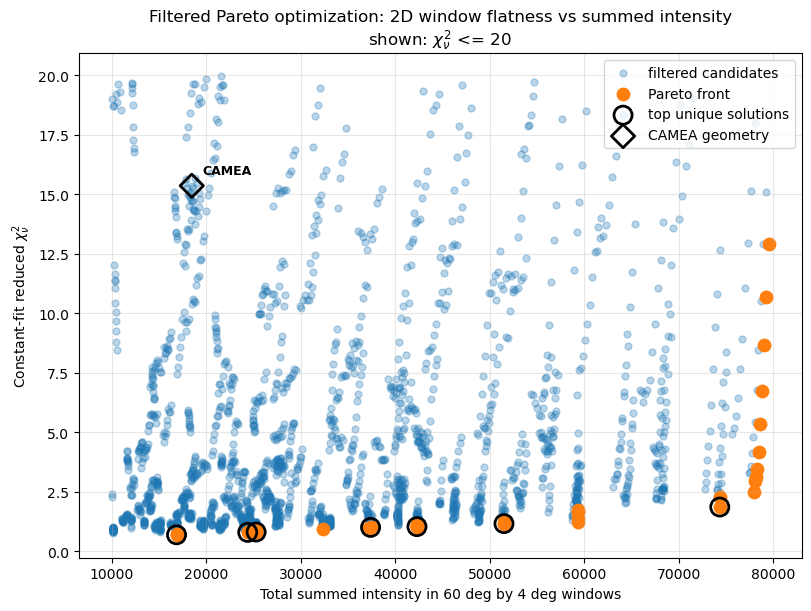

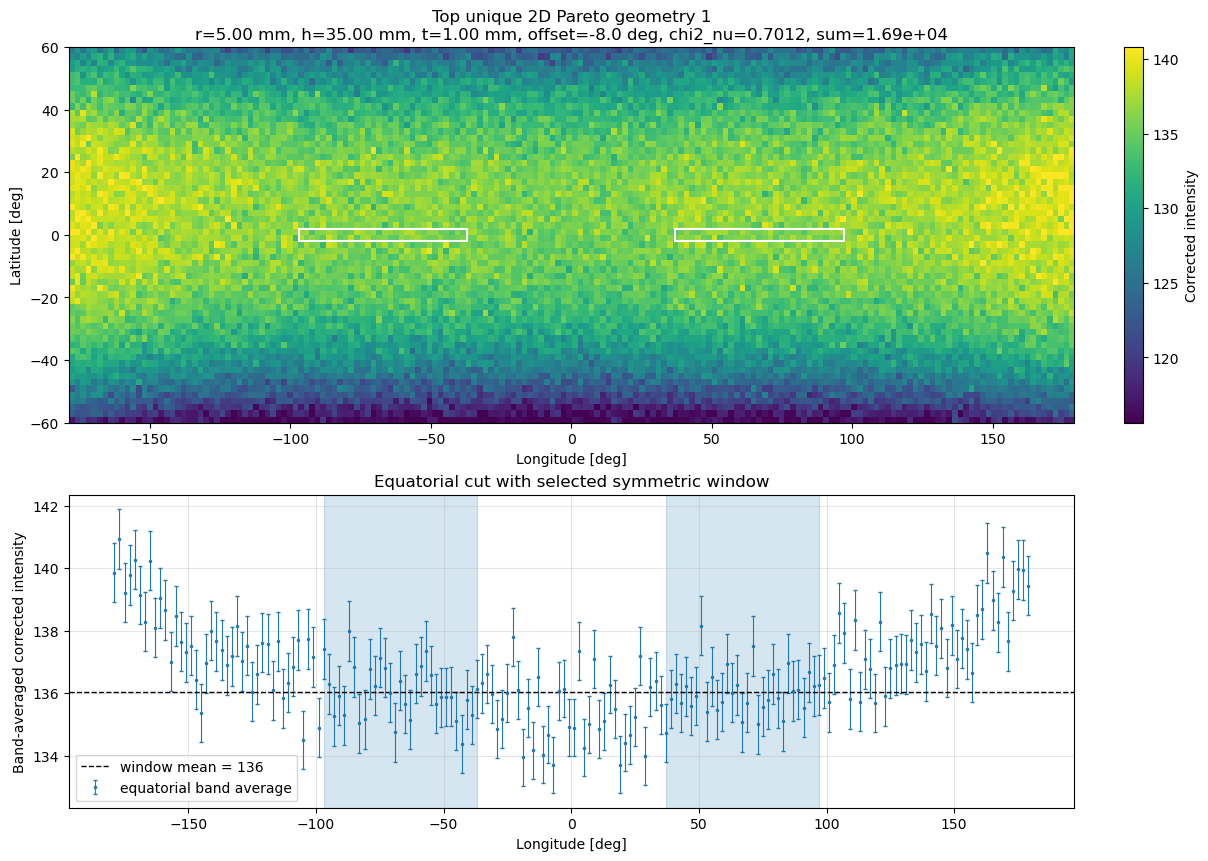

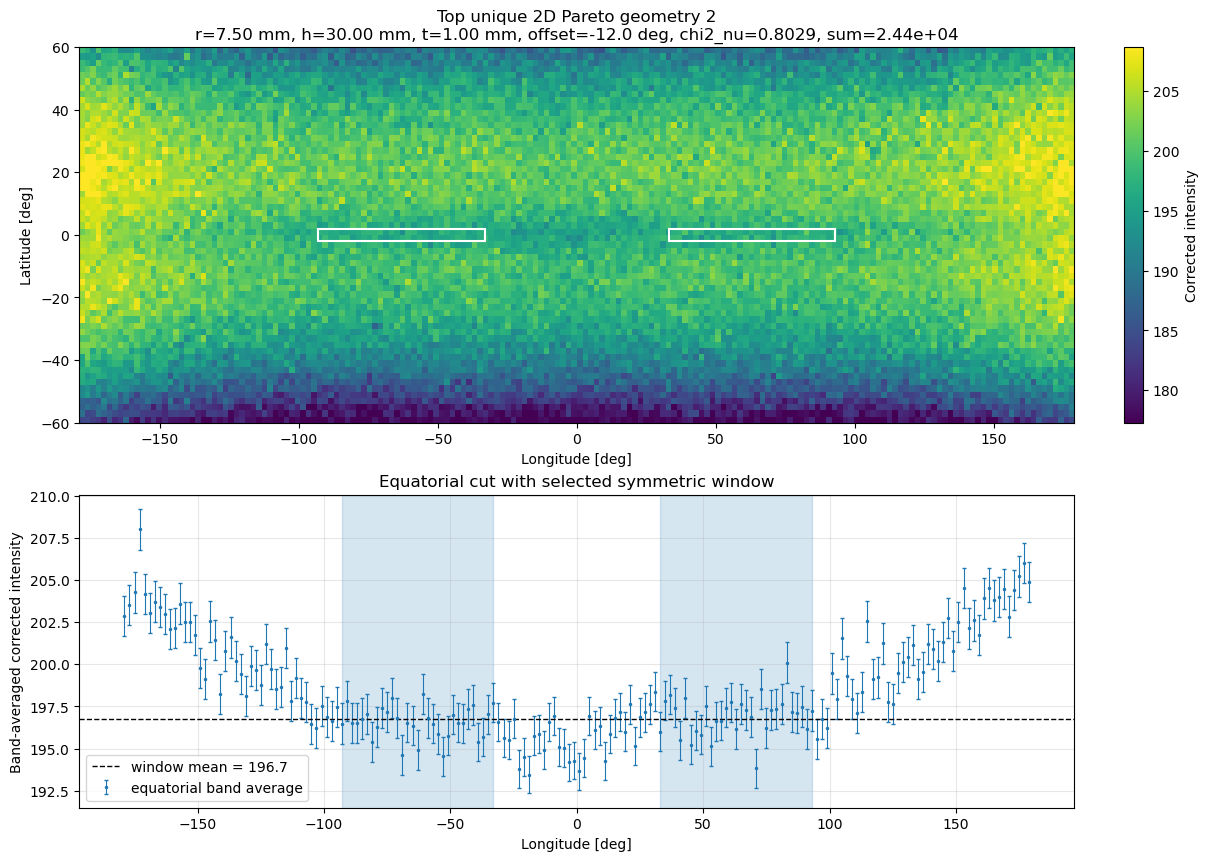

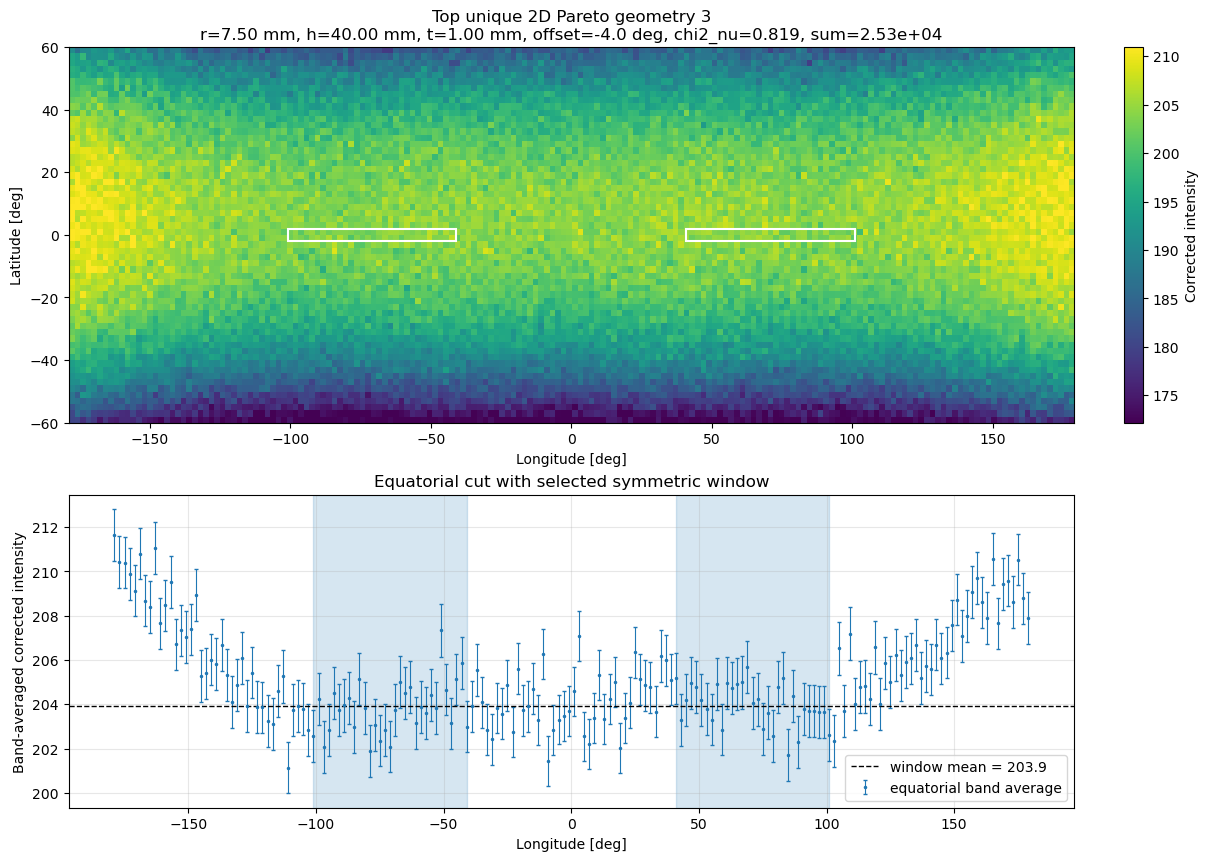

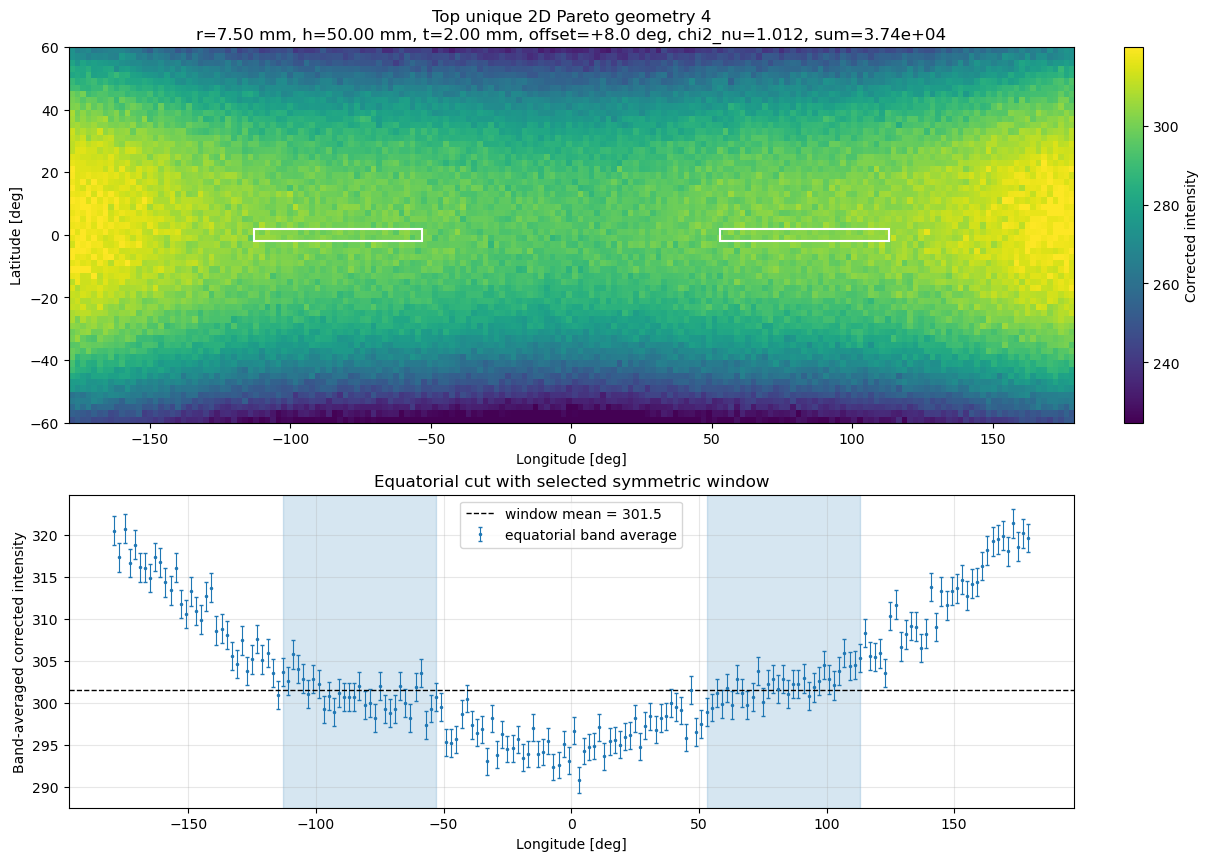

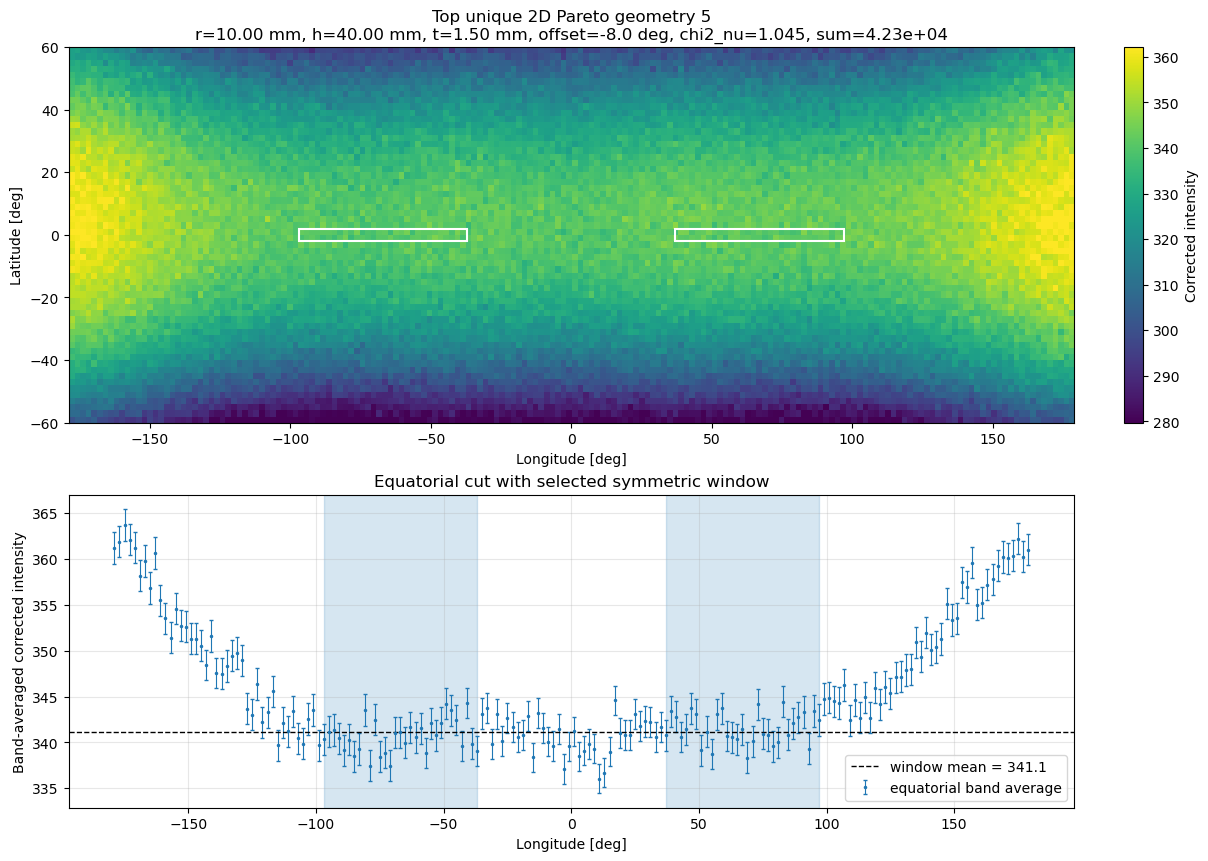

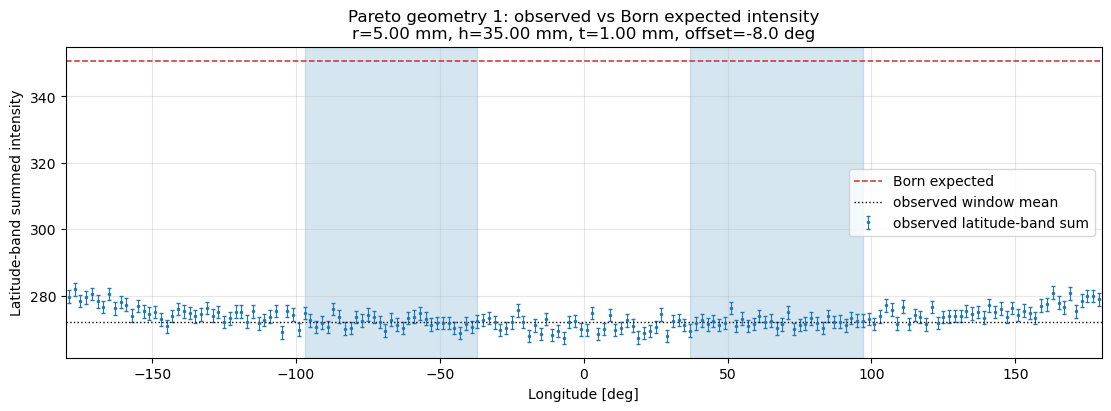

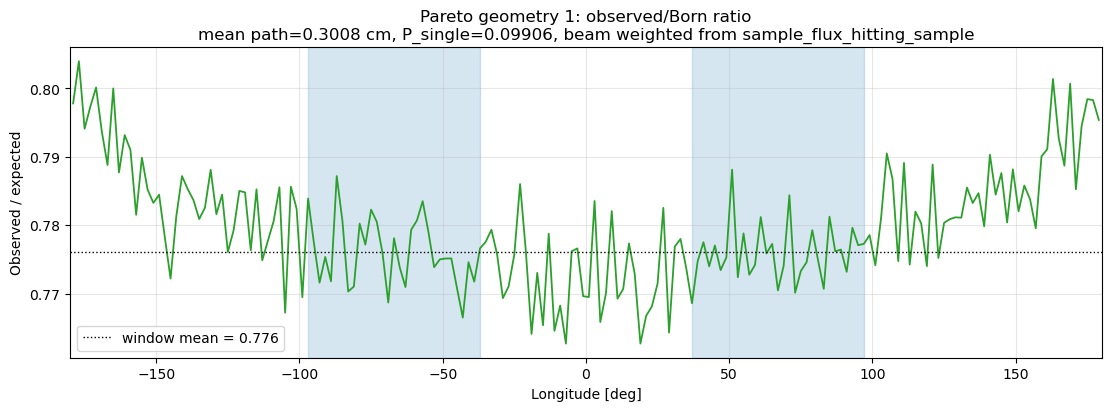

Geometry 1 Born profile summary: I_hit=1.82513e+07, V=1.09013 cm^3, mean_path=0.300822 cm, P_single=0.0990629, path_method=beam weighted from sample_flux_hitting_sample, expected_window_mean=350.605, observed_window_mean=272.077, observed/Born=0.776021


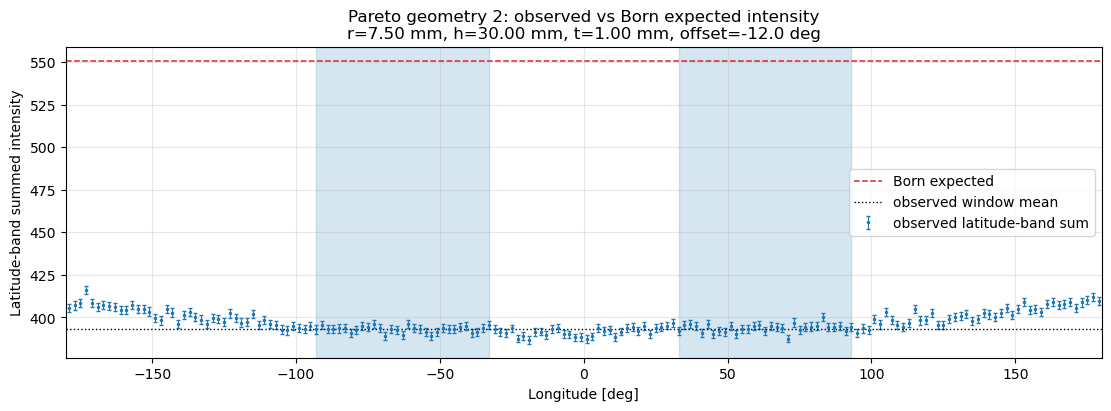

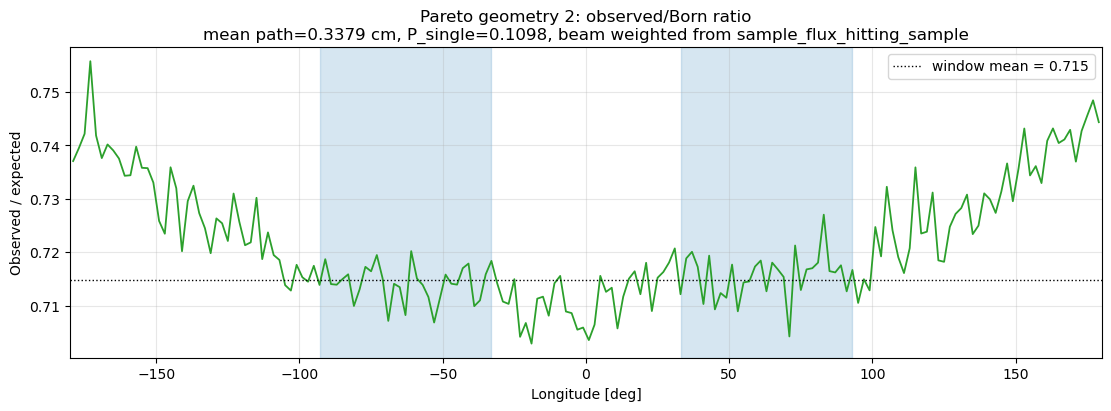

Geometry 2 Born profile summary: I_hit=2.58441e+07, V=1.58493 cm^3, mean_path=0.337928 cm, P_single=0.109835, path_method=beam weighted from sample_flux_hitting_sample, expected_window_mean=550.447, observed_window_mean=393.493, observed/Born=0.71486


In [59]:
# ============================================================
# Filtered Pareto front: 2D detector-window sum vs constant-fit chi2
# ============================================================

# This cell is self-contained so it can scan a different run folder from
# the profile-based Pareto cell above.

# ----------------------------
# 2D Pareto settings
# ----------------------------

psi_pareto_root = Path(
    '/Users/christian/Documents/Study/bachelor_project/geometry_optimization/PSI_instrument/scan_folder_5meV'
)

psi_monitor_name_candidates = (
    'sample_spherical_monitor_scattered',
    # 'sample_spherical_monitor',
    # 'cylinder_scattered',
)

psi_detector_window_center_deg = 75.0
psi_detector_center_offsets_deg = np.arange(-20.0, 20.1, 4.0)
psi_detector_window_width_deg = 60.0
psi_detector_latitude_halfwidth_deg = 2.0

psi_beam_mask_lon_halfwidth_deg = 2.0 # mask direct beam within this longitude range around 0 deg
psi_beam_mask_lat_halfwidth_deg = 4.0 # mask direct beam within this latitude range around 0 deg
psi_mask_direct_beam = False

psi_s_tol_value = 0.0
psi_i_tol_value = 0.0
psi_min_total_window_intensity = 1e4 # value for CAMEA geometry was 1.85e4

# Wavelength filter in Angstrom. Use None to keep all wavelengths,
# or e.g. 4.0 / 5.0 to keep one wavelength.
# The notebook derives wavelength from SourceE/EI when no explicit wavelength
# parameter is present in mccode.sim.
psi_wavelength_filter_angstrom = 4.0
psi_wavelength_tolerance_angstrom = 0.2

# Plot only candidates with reduced chi-square at or below this value.
# Set to None to show all filtered candidates.
psi_plot_max_reduced_chi_square = 20.0

psi_radius_bounds_mm = (0.0, np.inf)
psi_height_bounds_mm = (0.0, np.inf)
psi_thickness_bounds_mm = (0.0, np.inf)

# Optional reference run to mark on the 2D Pareto plot.
psi_camea_geometry_run_dir = psi_pareto_root / 'CAMEA_geometry'
psi_camea_geometry_offset_deg = 0.0

# Single-scattering expectation used for observed/expected deviation maps.
psi_sigma_inc_cm_inv = 0.367
psi_sigma_abs_cm_inv = psi_sigma_inc_cm_inv
psi_sigma_coh_cm_inv = 0.0
psi_sigma_total_cm_inv = psi_sigma_inc_cm_inv + psi_sigma_abs_cm_inv + psi_sigma_coh_cm_inv
psi_flux_monitor_candidates = ('sample_flux_hitting_sample', 'sample_flux_before')
# Use the sampled beam footprint when computing the Born mean path.
# This avoids counting lids or side-wall regions that the incoming beam does not illuminate.
psi_use_beam_weighted_born_path = True

# ----------------------------
# 2D Pareto helpers
# ----------------------------


def energy_mev_to_wavelength_angstrom(energy_mev):
    if energy_mev is None or energy_mev <= 0.0:
        return np.nan
    return np.sqrt(81.8042096 / energy_mev)


def parse_psi_geometry_from_mccode_sim(sim_file):

    params = {}
    pattern = re.compile(r'^\s*Param:\s*([A-Za-z0-9_]+)\s*=\s*([^,\s]+)')

    with sim_file.open('r') as f:
        for line in f:
            match = pattern.match(line)
            if not match:
                continue
            key = match.group(1).strip()
            raw_value = match.group(2).strip()
            try:
                params[key] = float(raw_value)
            except ValueError:
                pass

    radius_keys = ('sampleRadius', 'cylinder_radius')
    height_keys = ('sampleHeight', 'cylinder_height')
    thickness_keys = ('sampleThickness', 'thickness')
    wavelength_keys = ('wavelength', 'Wavelength', 'lambda', 'Lambda')
    energy_keys = ('SourceE', 'EI', 'E0', 'energy')

    def first_available(keys):
        for key in keys:
            if key in params:
                return params[key]
        raise ValueError(f'Missing one of {keys} in {sim_file}')

    wavelength_angstrom = np.nan
    wavelength_source = 'missing'

    for key in wavelength_keys:
        if key in params:
            wavelength_angstrom = params[key]
            wavelength_source = key
            break

    if not np.isfinite(wavelength_angstrom):
        for key in energy_keys:
            if key in params:
                wavelength_angstrom = energy_mev_to_wavelength_angstrom(params[key])
                wavelength_source = f'derived from {key}'
                break

    return {
        'outer_radius_mm': first_available(radius_keys) * 1000.0,
        'outer_height_mm': first_available(height_keys) * 1000.0,
        'wall_thickness_mm': first_available(thickness_keys) * 1000.0,
        'wavelength_angstrom': wavelength_angstrom,
        'wavelength_source': wavelength_source,
    }


def load_psi_monitor_from_run(run_dir):

    loaded = ms.load_data(str(run_dir))

    if not loaded:
        raise ValueError(f'No McStas data loaded from {run_dir}')

    for wanted in psi_monitor_name_candidates:
        for item in loaded:
            name = str(getattr(item, 'name', '') or '')
            component = str(getattr(item, 'component_name', '') or '')
            filename = str(getattr(item, 'filename', '') or '')
            if (
                wanted in name
                or wanted in component
                or wanted in filename
            ):
                return item

    names = [
        str(getattr(item, 'name', '') or getattr(item, 'component_name', '') or item)
        for item in loaded
    ]
    raise ValueError(
        f'None of {psi_monitor_name_candidates} found in {run_dir}. '
        f'Available records: {names}'
    )


def get_psi_corrected_heatmap_from_run(run_dir):

    sphere_mon = load_psi_monitor_from_run(run_dir)
    meta = sphere_mon.metadata

    H = np.array(sphere_mon.Intensity, copy=True)
    H_err = np.array(sphere_mon.Error, copy=True)

    if (
        hasattr(meta, 'dimension')
        and H.shape == (meta.dimension[0], meta.dimension[1])
    ):
        H = H.T
        H_err = H_err.T

    xmin, xmax, ymin, ymax = meta.limits

    lat_centers = np.linspace(
        ymin + 0.5 * (ymax - ymin) / H.shape[0],
        ymax - 0.5 * (ymax - ymin) / H.shape[0],
        H.shape[0],
    )

    lon_centers = np.linspace(
        xmin + 0.5 * (xmax - xmin) / H.shape[1],
        xmax - 0.5 * (xmax - xmin) / H.shape[1],
        H.shape[1],
    )

    cos_correction = np.cos(np.radians(lat_centers))[:, np.newaxis]
    safe_cos = np.where(np.abs(cos_correction) > 0, cos_correction, np.nan)

    H_corr = H / safe_cos
    H_err_corr = H_err / safe_cos

    if psi_mask_direct_beam:
        Lon, Lat = np.meshgrid(lon_centers, lat_centers)
        beam_center_mask = (
            (np.abs(Lon) <= psi_beam_mask_lon_halfwidth_deg)
            &
            (np.abs(Lat) <= psi_beam_mask_lat_halfwidth_deg)
        )
        H_corr = np.where(~beam_center_mask, H_corr, np.nan)
        H_err_corr = np.where(~beam_center_mask, H_err_corr, np.nan)

    return lon_centers, lat_centers, H_corr, H_err_corr


def psi_sample_material_volume_cm3_from_solution(solution):
    R = solution['outer_radius_mm'] / 10.0
    H = solution['outer_height_mm'] / 10.0
    t = solution['wall_thickness_mm'] / 10.0
    r = R - t
    H_inner = H - 2.0 * t
    if r <= 0.0 or H_inner < 0.0:
        return np.nan
    return np.pi * R**2 * H - np.pi * r**2 * H_inner


def psi_projected_area_cm2_from_solution(solution):
    R = solution['outer_radius_mm'] / 10.0
    H = solution['outer_height_mm'] / 10.0
    return 2.0 * R * H


def psi_mean_path_length_cm_from_solution(solution):
    return psi_sample_material_volume_cm3_from_solution(solution) / psi_projected_area_cm2_from_solution(solution)


def psi_material_path_map_cm(x_centers_cm, y_centers_cm, solution):
    x = np.asarray(x_centers_cm, dtype=float)
    y = np.asarray(y_centers_cm, dtype=float)

    R = solution['outer_radius_mm'] / 10.0
    H = solution['outer_height_mm'] / 10.0
    t = solution['wall_thickness_mm'] / 10.0
    r = max(R - t, 0.0)

    outer_chord = np.zeros_like(x, dtype=float)
    outer_mask = np.abs(x) <= R
    outer_chord[outer_mask] = 2.0 * np.sqrt(np.maximum(R**2 - x[outer_mask]**2, 0.0))

    inner_chord = np.zeros_like(x, dtype=float)
    inner_mask = np.abs(x) <= r
    inner_chord[inner_mask] = 2.0 * np.sqrt(np.maximum(r**2 - x[inner_mask]**2, 0.0))

    side_path = outer_chord - inner_chord
    in_outer_height = np.abs(y) <= 0.5 * H
    in_lid = (np.abs(y) >= 0.5 * H - t) & (np.abs(y) <= 0.5 * H) if t > 0.0 else np.zeros_like(y, dtype=bool)
    in_side_wall = in_outer_height & ~in_lid

    path = np.outer(in_side_wall.astype(float), side_path)
    path += np.outer(in_lid.astype(float), outer_chord)
    return path


def psi_monitor_xy_image_from_run(run_dir, name_candidates):
    loaded = ms.load_data(str(run_dir))
    for wanted in name_candidates:
        for item in loaded:
            name = str(getattr(item, 'name', '') or '')
            component = str(getattr(item, 'component_name', '') or '')
            filename = str(getattr(item, 'filename', '') or '')
            if wanted in name or wanted in component or wanted in filename:
                image = np.asarray(item.Intensity, dtype=float).copy()
                meta = item.metadata
                if hasattr(meta, 'dimension') and image.shape == (meta.dimension[0], meta.dimension[1]):
                    image = image.T
                xmin, xmax, ymin, ymax = meta.limits
                y_centers = np.linspace(
                    ymin + 0.5 * (ymax - ymin) / image.shape[0],
                    ymax - 0.5 * (ymax - ymin) / image.shape[0],
                    image.shape[0],
                )
                x_centers = np.linspace(
                    xmin + 0.5 * (xmax - xmin) / image.shape[1],
                    xmax - 0.5 * (xmax - xmin) / image.shape[1],
                    image.shape[1],
                )
                return x_centers, y_centers, image, wanted
    names = [str(getattr(item, 'name', '') or getattr(item, 'component_name', '') or item) for item in loaded]
    raise ValueError(f'None of {name_candidates} found in {run_dir}. Available records: {names}')


def psi_beam_weighted_mean_path_length_cm_from_solution(solution):
    x_centers, y_centers, weights, monitor_name = psi_monitor_xy_image_from_run(
        Path(solution['run_dir']),
        psi_flux_monitor_candidates,
    )
    path = psi_material_path_map_cm(x_centers, y_centers, solution)
    valid = np.isfinite(weights) & np.isfinite(path) & (weights > 0.0)
    total_weight = np.nansum(weights[valid])
    if total_weight <= 0.0:
        return np.nan, monitor_name
    return float(np.nansum(weights[valid] * path[valid]) / total_weight), monitor_name


def psi_born_mean_path_length_cm_from_solution(solution):
    if psi_use_beam_weighted_born_path:
        mean_path, monitor_name = psi_beam_weighted_mean_path_length_cm_from_solution(solution)
        if np.isfinite(mean_path):
            return mean_path, f'beam weighted from {monitor_name}'
    return psi_mean_path_length_cm_from_solution(solution), 'full volume / projected area'


def psi_single_scatter_probability_from_path_length(mean_path):
    total_interaction = 1.0 - np.exp(-psi_sigma_total_cm_inv * mean_path)
    return total_interaction * psi_sigma_inc_cm_inv / psi_sigma_total_cm_inv


def psi_record_total_from_run(run_dir, name_candidates):
    loaded = ms.load_data(str(run_dir))
    for wanted in name_candidates:
        for item in loaded:
            name = str(getattr(item, 'name', '') or '')
            component = str(getattr(item, 'component_name', '') or '')
            filename = str(getattr(item, 'filename', '') or '')
            if wanted in name or wanted in component or wanted in filename:
                return float(np.nansum(np.asarray(item.Intensity, dtype=float)))
    names = [str(getattr(item, 'name', '') or getattr(item, 'component_name', '') or item) for item in loaded]
    raise ValueError(f'None of {name_candidates} found in {run_dir}. Available records: {names}')


def psi_corrected_single_scattering_expected_map(solution, lon, lat):
    run_dir = Path(solution['run_dir'])
    hit_intensity = psi_record_total_from_run(run_dir, psi_flux_monitor_candidates)
    mean_path, path_method = psi_born_mean_path_length_cm_from_solution(solution)
    probability = psi_single_scatter_probability_from_path_length(mean_path)

    if lon.size < 2 or lat.size < 2:
        raise ValueError('Need at least two longitude and latitude bins for solid-angle estimate')

    dlon_rad = np.deg2rad(np.nanmedian(np.diff(lon)))
    dlat_rad = np.deg2rad(np.nanmedian(np.diff(lat)))
    lat_rad = np.deg2rad(lat)
    lat_low = lat_rad - 0.5 * dlat_rad
    lat_high = lat_rad + 0.5 * dlat_rad
    solid_angle_by_lat = dlon_rad * (np.sin(lat_high) - np.sin(lat_low))
    cos_lat = np.cos(lat_rad)
    corrected_solid_angle_by_lat = solid_angle_by_lat / np.where(np.abs(cos_lat) > 0.0, cos_lat, np.nan)

    expected_by_lat = hit_intensity * probability * corrected_solid_angle_by_lat / (4.0 * np.pi)
    expected_map = np.repeat(expected_by_lat[:, np.newaxis], lon.size, axis=1)
    return expected_map, {
        'hit_intensity': hit_intensity,
        'probability': probability,
        'mean_path_cm': mean_path,
        'path_method': path_method,
        'full_volume_mean_path_cm': psi_mean_path_length_cm_from_solution(solution),
        'material_volume_cm3': psi_sample_material_volume_cm3_from_solution(solution),
    }


def psi_window_2d_metrics_from_run(run_dir, center_deg):

    lon, lat, H, H_err = get_psi_corrected_heatmap_from_run(run_dir)

    half_lon = psi_detector_window_width_deg / 2.0
    half_lat = psi_detector_latitude_halfwidth_deg

    pos_min = center_deg - half_lon
    pos_max = center_deg + half_lon
    neg_min = -pos_max
    neg_max = -pos_min

    Lon, Lat = np.meshgrid(lon, lat)

    window_mask = (
        (np.abs(Lat) <= half_lat)
        &
        (
            ((Lon >= pos_min) & (Lon <= pos_max))
            |
            ((Lon >= neg_min) & (Lon <= neg_max))
        )
    )

    y_all = H[window_mask]
    err_all = H_err[window_mask]

    valid_intensity = np.isfinite(y_all) & (y_all > 0.0)
    total_window_intensity = np.nansum(y_all[valid_intensity])

    valid_fit = (
        valid_intensity
        &
        np.isfinite(err_all)
        &
        (err_all > 0.0)
    )

    y_fit = y_all[valid_fit]
    err_fit = err_all[valid_fit]

    if y_fit.size < 2:
        return None

    window_fit_mean = np.mean(y_fit)
    window_fit_min = np.min(y_fit)
    window_fit_max = np.max(y_fit)
    window_peak_to_peak = window_fit_max - window_fit_min
    window_max_abs_deviation = np.max(np.abs(y_fit - window_fit_mean))
    if window_fit_mean > 0.0:
        window_peak_to_peak_relative = window_peak_to_peak / window_fit_mean
        window_max_abs_deviation_relative = window_max_abs_deviation / window_fit_mean
    else:
        window_peak_to_peak_relative = np.nan
        window_max_abs_deviation_relative = np.nan

    weights = 1.0 / err_fit**2
    constant_fit = np.sum(weights * y_fit) / np.sum(weights)
    chi2 = np.sum(((y_fit - constant_fit) / err_fit)**2)
    reduced_chi_square = chi2 / (y_fit.size - 1)

    if not np.isfinite(reduced_chi_square):
        return None

    return {
        'center_deg': center_deg,
        'pos_min': pos_min,
        'pos_max': pos_max,
        'neg_min': neg_min,
        'neg_max': neg_max,
        'constant_fit': constant_fit,
        'reduced_chi_square_2d': reduced_chi_square,
        'total_window_intensity': total_window_intensity,
        'window_fit_mean': window_fit_mean,
        'window_peak_to_peak_relative': window_peak_to_peak_relative,
        'window_max_abs_deviation': window_max_abs_deviation,
        'window_max_abs_deviation_relative': window_max_abs_deviation_relative,
        'n_window_pixels': int(np.sum(window_mask)),
        'n_fit_pixels': int(y_fit.size),
        'S': reduced_chi_square,
    }


# ----------------------------
# Parse PSI runs
# ----------------------------

psi_sim_files = sorted(psi_pareto_root.glob('**/mccode.sim'))
psi_records_2d_unfiltered = []

for sim_file in psi_sim_files:

    run_dir = sim_file.parent

    try:
        geom = parse_psi_geometry_from_mccode_sim(sim_file)
        # Load once here to skip broken runs before scanning offsets.
        get_psi_corrected_heatmap_from_run(run_dir)
    except Exception:
        continue

    for offset_deg in psi_detector_center_offsets_deg:

        center_deg = psi_detector_window_center_deg + offset_deg
        metrics = psi_window_2d_metrics_from_run(run_dir, center_deg)

        if metrics is None:
            continue

        metrics.update({
            'offset_deg': offset_deg,
            'run_dir': str(run_dir),
            'geometry_dir': str(run_dir.parent),
            **geom,
        })

        psi_records_2d_unfiltered.append(metrics)


psi_records_2d = [
    r for r in psi_records_2d_unfiltered
    if (
        r['total_window_intensity'] >= psi_min_total_window_intensity
        and (
            psi_wavelength_filter_angstrom is None
            or (
                np.isfinite(r['wavelength_angstrom'])
                and abs(r['wavelength_angstrom'] - psi_wavelength_filter_angstrom)
                <= psi_wavelength_tolerance_angstrom
            )
        )
        and psi_radius_bounds_mm[0] <= r['outer_radius_mm'] <= psi_radius_bounds_mm[1]
        and psi_height_bounds_mm[0] <= r['outer_height_mm'] <= psi_height_bounds_mm[1]
        and psi_thickness_bounds_mm[0] <= r['wall_thickness_mm'] <= psi_thickness_bounds_mm[1]
    )
]

psi_camea_geometry_record = None
if psi_camea_geometry_run_dir is not None and Path(psi_camea_geometry_run_dir).exists():
    try:
        _camea_run_dir = Path(psi_camea_geometry_run_dir)
        _camea_geom = parse_psi_geometry_from_mccode_sim(_camea_run_dir / 'mccode.sim')
        _camea_center = psi_detector_window_center_deg + psi_camea_geometry_offset_deg
        psi_camea_geometry_record = psi_window_2d_metrics_from_run(_camea_run_dir, _camea_center)
        if psi_camea_geometry_record is not None:
            psi_camea_geometry_record.update({
                'offset_deg': psi_camea_geometry_offset_deg,
                'run_dir': str(_camea_run_dir),
                'geometry_dir': str(_camea_run_dir),
                **_camea_geom,
            })
    except Exception as exc:
        print(f'CAMEA geometry marker skipped: {exc}')

print(f'2D Pareto root: {psi_pareto_root}')
print(f'Found mccode.sim files: {len(psi_sim_files)}')
if psi_records_2d_unfiltered:
    wavelengths_found = sorted({
        round(r['wavelength_angstrom'], 3)
        for r in psi_records_2d_unfiltered
        if np.isfinite(r['wavelength_angstrom'])
    })
else:
    wavelengths_found = []

print(f'2D candidate windows before filtering: {len(psi_records_2d_unfiltered)}')
print(f'2D candidate windows after filtering:  {len(psi_records_2d)}')
print(f'Wavelengths found [Angstrom]: {wavelengths_found}')

if psi_records_2d_unfiltered:
    _filter_arrays = {
        'total_window_intensity': np.array([r['total_window_intensity'] for r in psi_records_2d_unfiltered], dtype=float),
        'wavelength_angstrom': np.array([r['wavelength_angstrom'] for r in psi_records_2d_unfiltered], dtype=float),
        'outer_radius_mm': np.array([r['outer_radius_mm'] for r in psi_records_2d_unfiltered], dtype=float),
        'outer_height_mm': np.array([r['outer_height_mm'] for r in psi_records_2d_unfiltered], dtype=float),
        'wall_thickness_mm': np.array([r['wall_thickness_mm'] for r in psi_records_2d_unfiltered], dtype=float),
        'reduced_chi_square_2d': np.array([r['reduced_chi_square_2d'] for r in psi_records_2d_unfiltered], dtype=float),
    }
    _filter_masks = {
        'intensity': _filter_arrays['total_window_intensity'] >= psi_min_total_window_intensity,
        'wavelength': (
            psi_wavelength_filter_angstrom is None
            or (
                np.isfinite(_filter_arrays['wavelength_angstrom'])
                & (np.abs(_filter_arrays['wavelength_angstrom'] - psi_wavelength_filter_angstrom) <= psi_wavelength_tolerance_angstrom)
            )
        ),
        'radius': (psi_radius_bounds_mm[0] <= _filter_arrays['outer_radius_mm']) & (_filter_arrays['outer_radius_mm'] <= psi_radius_bounds_mm[1]),
        'height': (psi_height_bounds_mm[0] <= _filter_arrays['outer_height_mm']) & (_filter_arrays['outer_height_mm'] <= psi_height_bounds_mm[1]),
        'thickness': (psi_thickness_bounds_mm[0] <= _filter_arrays['wall_thickness_mm']) & (_filter_arrays['wall_thickness_mm'] <= psi_thickness_bounds_mm[1]),
    }
    print('2D filter diagnostics before filtering:')
    for _key, _values in _filter_arrays.items():
        print(f"  {_key:<24} min={np.nanmin(_values):.6g}, max={np.nanmax(_values):.6g}")
    _cumulative = np.ones(len(psi_records_2d_unfiltered), dtype=bool)
    for _name, _mask in _filter_masks.items():
        _mask = np.asarray(_mask, dtype=bool)
        _cumulative &= _mask
        print(
            f"  filter {_name:<10}: pass={np.count_nonzero(_mask):4d}, "
            f"fail={np.count_nonzero(~_mask):4d}, cumulative={np.count_nonzero(_cumulative):4d}"
        )
print(
    'Wavelength filter [Angstrom]: '
    f'{psi_wavelength_filter_angstrom} '
    f'+/- {psi_wavelength_tolerance_angstrom}'
)
print(
    '2D window: '
    f'center={psi_detector_window_center_deg:g} deg, '
    f'offsets=[{psi_detector_center_offsets_deg.min():g}, {psi_detector_center_offsets_deg.max():g}] deg, '
    f'width={psi_detector_window_width_deg:g} deg, '
    f'latitude half-width={psi_detector_latitude_halfwidth_deg:g} deg'
)

if not psi_records_2d:

    print('No valid 2D-window candidates found.')

else:

    S_2d = np.array([r['reduced_chi_square_2d'] for r in psi_records_2d])
    I_2d = np.array([r['total_window_intensity'] for r in psi_records_2d])

    pareto_idx_2d = pareto_front_indices(
        S_2d,
        I_2d,
        s_tol=psi_s_tol_value,
        i_tol=psi_i_tol_value,
    )

    pareto_records_2d = sorted(
        [psi_records_2d[i] for i in pareto_idx_2d],
        key=lambda r: r['reduced_chi_square_2d'],
    )

    unique_pareto_2d_by_radius_height = {}

    for r in pareto_records_2d:

        radius_height_key = (
            round(r['outer_radius_mm'], 6),
            round(r['outer_height_mm'], 6),
        )

        current = unique_pareto_2d_by_radius_height.get(radius_height_key)

        if (
            current is None
            or
            (
                r['reduced_chi_square_2d'],
                -r['total_window_intensity'],
            )
            <
            (
                current['reduced_chi_square_2d'],
                -current['total_window_intensity'],
            )
        ):
            unique_pareto_2d_by_radius_height[radius_height_key] = r

    top_unique_2d = sorted(
        unique_pareto_2d_by_radius_height.values(),
        key=lambda r: r['reduced_chi_square_2d'],
    )[:10]

    print(f'2D-window Pareto front size: {len(pareto_records_2d)}')
    print('\nTop 10 unique 2D-window Pareto geometries:\n')

    for i, r in enumerate(top_unique_2d, start=1):
        print(
            f"{i}. "
            f"r={r['outer_radius_mm']:.2f} mm, "
            f"h={r['outer_height_mm']:.2f} mm, "
            f"t={r['wall_thickness_mm']:.2f} mm, "
            f"lambda={r['wavelength_angstrom']:.3g} A, "
            f"offset={r['offset_deg']:+.1f} deg, "
            f"chi2_nu={r['reduced_chi_square_2d']:.5g}, "
            f"sum={r['total_window_intensity']:.3e}, "
            f"pixels={r['n_fit_pixels']}"
        )
        print(
            f"   peak-to-peak/mean={r['window_peak_to_peak_relative']:.6g}, "
            f"max abs deviation/mean={r['window_max_abs_deviation_relative']:.6g}, "
            f"max abs deviation={r['window_max_abs_deviation']:.6g}"
        )
        print(f"   path={r['run_dir']}")

    if psi_plot_max_reduced_chi_square is None:
        plot_records_2d = psi_records_2d
        plot_pareto_records_2d = pareto_records_2d
        plot_top_unique_2d = top_unique_2d
    else:
        plot_records_2d = [
            r for r in psi_records_2d
            if r['reduced_chi_square_2d'] <= psi_plot_max_reduced_chi_square
        ]
        plot_pareto_records_2d = [
            r for r in pareto_records_2d
            if r['reduced_chi_square_2d'] <= psi_plot_max_reduced_chi_square
        ]
        plot_top_unique_2d = [
            r for r in top_unique_2d
            if r['reduced_chi_square_2d'] <= psi_plot_max_reduced_chi_square
        ]

    print(
        f'2D plot candidates shown: {len(plot_records_2d)} / {len(psi_records_2d)}'
    )
    if psi_camea_geometry_record is not None:
        print(
            'CAMEA geometry marker: '
            f"r={psi_camea_geometry_record['outer_radius_mm']:.2f} mm, "
            f"h={psi_camea_geometry_record['outer_height_mm']:.2f} mm, "
            f"t={psi_camea_geometry_record['wall_thickness_mm']:.2f} mm, "
            f"offset={psi_camea_geometry_record['offset_deg']:+.1f} deg, "
            f"chi2_nu={psi_camea_geometry_record['reduced_chi_square_2d']:.5g}, "
            f"sum={psi_camea_geometry_record['total_window_intensity']:.3e}"
        )

    fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)

    ax.scatter(
        [r['total_window_intensity'] for r in plot_records_2d],
        [r['reduced_chi_square_2d'] for r in plot_records_2d],
        s=25,
        alpha=0.3,
        label='filtered candidates',
    )

    ax.scatter(
        [r['total_window_intensity'] for r in plot_pareto_records_2d],
        [r['reduced_chi_square_2d'] for r in plot_pareto_records_2d],
        s=80,
        label='Pareto front',
    )

    ax.scatter(
        [r['total_window_intensity'] for r in plot_top_unique_2d],
        [r['reduced_chi_square_2d'] for r in plot_top_unique_2d],
        marker='o',
        s=170,
        facecolor='none',
        edgecolor='black',
        linewidth=2.0,
        label='top unique solutions',
    )

    if psi_camea_geometry_record is not None:
        ax.scatter(
            [psi_camea_geometry_record['total_window_intensity']],
            [psi_camea_geometry_record['reduced_chi_square_2d']],
            marker='D',
            s=140,
            facecolor='none',
            edgecolor='black',
            linewidth=2.0,
            label='CAMEA geometry',
            zorder=6,
        )
        ax.annotate(
            'CAMEA',
            (
                psi_camea_geometry_record['total_window_intensity'],
                psi_camea_geometry_record['reduced_chi_square_2d'],
            ),
            xytext=(8, 8),
            textcoords='offset points',
            fontsize=9,
            weight='bold',
        )

    ax.set_xlabel(
        f'Total summed intensity in {psi_detector_window_width_deg:g} deg '
        f'by {2.0 * psi_detector_latitude_halfwidth_deg:g} deg windows'
    )
    ax.set_ylabel(r'Constant-fit reduced $\chi^2_\nu$')
    title = 'Filtered Pareto optimization: 2D window flatness vs summed intensity'
    if psi_plot_max_reduced_chi_square is not None:
        title += f'\nshown: $\\chi^2_\\nu$ <= {psi_plot_max_reduced_chi_square:g}'
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend()

    plt.show()

    def plot_2d_pareto_geometry(solution, index):
        lon, lat, H, H_err = get_psi_corrected_heatmap_from_run(Path(solution['run_dir']))

        band_mask = np.abs(lat) <= psi_detector_latitude_halfwidth_deg
        profile = np.nanmean(H[band_mask, :], axis=0)
        if H_err is not None:
            profile_err = np.sqrt(np.nansum(H_err[band_mask, :] ** 2, axis=0)) / max(np.count_nonzero(band_mask), 1)
        else:
            profile_err = None

        pos_min = solution['pos_min']
        pos_max = solution['pos_max']
        neg_min = solution['neg_min']
        neg_max = solution['neg_max']
        window_mask = ((lon >= pos_min) & (lon <= pos_max)) | ((lon >= neg_min) & (lon <= neg_max))
        window_mean = np.nanmean(profile[window_mask])

        fig, axes = plt.subplots(
            2,
            1,
            figsize=(12, 8.5),
            gridspec_kw={'height_ratios': [1.2, 1.0]},
            constrained_layout=True,
        )

        display_lat_min, display_lat_max = -60.0, 60.0
        display_lat_mask = (lat >= display_lat_min) & (lat <= display_lat_max)
        H_display = H[display_lat_mask, :]
        vmin, vmax = np.nanpercentile(H_display, [1.0, 99.5])
        im = axes[0].imshow(
            H_display,
            origin='lower',
            aspect='auto',
            extent=[lon.min(), lon.max(), display_lat_min, display_lat_max],
            interpolation='nearest',
            cmap='viridis',
            vmin=vmin,
            vmax=vmax,
        )
        # axes[0].axhline(0.0, color='white', linestyle=':', linewidth=1.0, alpha=0.9)
        # axes[0].axhline(psi_detector_latitude_halfwidth_deg, color='white', linestyle=':', linewidth=0.9, alpha=0.9)
        # axes[0].axhline(-psi_detector_latitude_halfwidth_deg, color='white', linestyle=':', linewidth=0.9, alpha=0.9)
        for xmin_win, xmax_win in [(pos_min, pos_max), (neg_min, neg_max)]:
            axes[0].add_patch(Rectangle(
                (xmin_win, -psi_detector_latitude_halfwidth_deg),
                xmax_win - xmin_win,
                2.0 * psi_detector_latitude_halfwidth_deg,
                fill=False,
                edgecolor='white',
                linewidth=1.5,
            ))
        axes[0].set_title(
            f'Top unique 2D Pareto geometry {index}\n'
            f"r={solution['outer_radius_mm']:.2f} mm, "
            f"h={solution['outer_height_mm']:.2f} mm, "
            f"t={solution['wall_thickness_mm']:.2f} mm, "
            f"offset={solution['offset_deg']:+.1f} deg, "
            f"chi2_nu={solution['reduced_chi_square_2d']:.4g}, "
            f"sum={solution['total_window_intensity']:.3g}"
        )
        axes[0].set_xlabel('Longitude [deg]')
        axes[0].set_ylabel('Latitude [deg]')
        fig.colorbar(im, ax=axes[0], label='Corrected intensity')

        valid = np.isfinite(profile)
        if profile_err is not None:
            axes[1].errorbar(
                lon[valid],
                profile[valid],
                yerr=profile_err[valid],
                fmt='.',
                markersize=3,
                linewidth=0.8,
                capsize=1.5,
                label='equatorial band average',
            )
        else:
            axes[1].plot(lon[valid], profile[valid], '.', markersize=3, label='equatorial band average')
        axes[1].axvspan(pos_min, pos_max, alpha=0.18, color='tab:blue')
        axes[1].axvspan(neg_min, neg_max, alpha=0.18, color='tab:blue')
        axes[1].axhline(window_mean, color='black', linestyle='--', linewidth=1.0, label=f'window mean = {window_mean:.4g}')
        axes[1].set_title('Equatorial cut with selected symmetric window')
        axes[1].set_xlabel('Longitude [deg]')
        axes[1].set_ylabel('Band-averaged corrected intensity')
        axes[1].grid(True, alpha=0.3)
        axes[1].legend(loc='best')

        plt.show()

    for i, solution in enumerate(top_unique_2d[:5], start=1):
        plot_2d_pareto_geometry(solution, i)

    def plot_observed_vs_born_profile(solution, index):
        lon, lat, H, H_err = get_psi_corrected_heatmap_from_run(Path(solution['run_dir']))
        expected_map, expected_info = psi_corrected_single_scattering_expected_map(solution, lon, lat)

        band_mask = np.abs(lat) <= psi_detector_latitude_halfwidth_deg
        observed_profile = np.nansum(H[band_mask, :], axis=0)
        expected_profile = np.nansum(expected_map[band_mask, :], axis=0)
        if H_err is not None:
            observed_profile_err = np.sqrt(np.nansum(H_err[band_mask, :] ** 2, axis=0))
        else:
            observed_profile_err = None

        pos_min = solution['pos_min']
        pos_max = solution['pos_max']
        neg_min = solution['neg_min']
        neg_max = solution['neg_max']
        window_mask = ((lon >= pos_min) & (lon <= pos_max)) | ((lon >= neg_min) & (lon <= neg_max))

        valid = np.isfinite(observed_profile) & np.isfinite(expected_profile) & (expected_profile > 0.0) & (observed_profile != 0.0)
        observed_window_mean = np.nanmean(observed_profile[window_mask])
        expected_window_mean = np.nanmean(expected_profile[window_mask])
        ratio_values = np.full_like(observed_profile, np.nan, dtype=float)
        ratio_values[valid] = observed_profile[valid] / expected_profile[valid]
        ratio_window_mean = np.nanmean(ratio_values[window_mask])

        fig, ax = plt.subplots(figsize=(11, 4.0), constrained_layout=True)
        if observed_profile_err is not None:
            ax.errorbar(
                lon[valid],
                observed_profile[valid],
                yerr=observed_profile_err[valid],
                fmt='.',
                markersize=3,
                linewidth=0.8,
                capsize=1.5,
                label='observed latitude-band sum',
            )
        else:
            ax.plot(lon[valid], observed_profile[valid], '.', markersize=3, label='observed latitude-band sum')
        ax.axhline(expected_window_mean, color='tab:red', linestyle='--', linewidth=1.1, label='Born expected')
        ax.axhline(observed_window_mean, color='black', linestyle=':', linewidth=1.0, label='observed window mean')
        ax.axvspan(pos_min, pos_max, alpha=0.18, color='tab:blue')
        ax.axvspan(neg_min, neg_max, alpha=0.18, color='tab:blue')
        ax.set_title(
            f'Pareto geometry {index}: observed vs Born expected intensity\n'
            f"r={solution['outer_radius_mm']:.2f} mm, "
            f"h={solution['outer_height_mm']:.2f} mm, "
            f"t={solution['wall_thickness_mm']:.2f} mm, "
            f"offset={solution['offset_deg']:+.1f} deg"
        )
        ax.set_xlabel('Longitude [deg]')
        ax.set_ylabel('Latitude-band summed intensity')
        ax.set_xlim(-180, 180)
        ax.grid(True, alpha=0.3)
        ax.legend(loc='best')
        plt.show()

        fig, ax = plt.subplots(figsize=(11, 4.0), constrained_layout=True)
        ax.plot(lon[valid], ratio_values[valid], color='tab:green', lw=1.3)
        ax.axhline(ratio_window_mean, color='black', linestyle=':', linewidth=1.0, label=f'window mean = {ratio_window_mean:.3g}')
        ax.axvspan(pos_min, pos_max, alpha=0.18, color='tab:blue')
        ax.axvspan(neg_min, neg_max, alpha=0.18, color='tab:blue')
        ax.set_title(
            f'Pareto geometry {index}: observed/Born ratio\n'
            f"mean path={expected_info['mean_path_cm']:.4g} cm, "
            f"P_single={expected_info['probability']:.4g}, "
            f"{expected_info['path_method']}"
        )
        ax.set_xlabel('Longitude [deg]')
        ax.set_ylabel('Observed / expected')
        ax.set_xlim(-180, 180)
        ax.grid(True, alpha=0.3)
        ax.legend(loc='best')
        plt.show()

        print(
            f"Geometry {index} Born profile summary: "
            f"I_hit={expected_info['hit_intensity']:.6g}, "
            f"V={expected_info['material_volume_cm3']:.6g} cm^3, "
            f"mean_path={expected_info['mean_path_cm']:.6g} cm, "
            f"P_single={expected_info['probability']:.6g}, "
            f"path_method={expected_info['path_method']}, "
            f"expected_window_mean={expected_window_mean:.6g}, "
            f"observed_window_mean={observed_window_mean:.6g}, "
            f"observed/Born={ratio_window_mean:.6g}"
        )

    for i, solution in enumerate(top_unique_2d[:2], start=1):
        plot_observed_vs_born_profile(solution, i)


In [ ]:
# ============================================================
# Filtered Pareto front: 2D detector-window sum vs constant-fit chi2
# ============================================================

# This cell is self-contained so it can scan a different run folder from
# the profile-based Pareto cell above.

# ----------------------------
# 2D Pareto settings
# ----------------------------

psi_pareto_root = Path(
    '/Users/christian/Documents/Study/bachelor_project/geometry_optimization/PSI_instrument/scan_folder_5meV'
)

psi_monitor_name_candidates = (
    'sample_spherical_monitor_scattered',
    # 'sample_spherical_monitor',
    # 'cylinder_scattered',
)

psi_detector_window_center_deg = 75.0
psi_detector_center_offsets_deg = np.arange(-20.0, 20.1, 4.0)
psi_detector_window_width_deg = 60.0
psi_detector_latitude_halfwidth_deg = 2.0

psi_beam_mask_lon_halfwidth_deg = 2.0 # mask direct beam within this longitude range around 0 deg
psi_beam_mask_lat_halfwidth_deg = 4.0 # mask direct beam within this latitude range around 0 deg
psi_mask_direct_beam = False

psi_s_tol_value = 0.1
psi_i_tol_value = 0.01
psi_min_total_window_intensity = 8e3 # value for CAMEA geometry was 1.85e4

# Wavelength filter in Angstrom. Use None to keep all wavelengths,
# or e.g. 4.0 / 5.0 to keep one wavelength.
# The notebook derives wavelength from SourceE/EI when no explicit wavelength
# parameter is present in mccode.sim.
psi_wavelength_filter_angstrom = 5.0
psi_wavelength_tolerance_angstrom = 0.5

# Plot only candidates with reduced chi-square at or below this value.
# Set to None to show all filtered candidates.
psi_plot_max_reduced_chi_square = 10.0

psi_radius_bounds_mm = (4.9, 21.1)
psi_height_bounds_mm = (4.9, 61.1)
psi_thickness_bounds_mm = (0.9, 4.1)

# Optional reference run to mark on the 2D Pareto plot.
psi_camea_geometry_run_dir = psi_pareto_root / 'CAMEA_geometry'
psi_camea_geometry_offset_deg = 0.0

# Single-scattering expectation used for observed/expected deviation maps.
psi_sigma_inc_cm_inv = 0.367
psi_sigma_abs_cm_inv = psi_sigma_inc_cm_inv
psi_sigma_coh_cm_inv = 0.0
psi_sigma_total_cm_inv = psi_sigma_inc_cm_inv + psi_sigma_abs_cm_inv + psi_sigma_coh_cm_inv
psi_flux_monitor_candidates = ('sample_flux_hitting_sample', 'sample_flux_before')
# Use the sampled beam footprint when computing the Born mean path.
# This avoids counting lids or side-wall regions that the incoming beam does not illuminate.
psi_use_beam_weighted_born_path = True

# ----------------------------
# 2D Pareto helpers
# ----------------------------


def energy_mev_to_wavelength_angstrom(energy_mev):
    if energy_mev is None or energy_mev <= 0.0:
        return np.nan
    return np.sqrt(81.8042096 / energy_mev)


def parse_psi_geometry_from_mccode_sim(sim_file):

    params = {}
    pattern = re.compile(r'^\s*Param:\s*([A-Za-z0-9_]+)\s*=\s*([^,\s]+)')

    with sim_file.open('r') as f:
        for line in f:
            match = pattern.match(line)
            if not match:
                continue
            key = match.group(1).strip()
            raw_value = match.group(2).strip()
            try:
                params[key] = float(raw_value)
            except ValueError:
                pass

    radius_keys = ('sampleRadius', 'cylinder_radius')
    height_keys = ('sampleHeight', 'cylinder_height')
    thickness_keys = ('sampleThickness', 'thickness')
    wavelength_keys = ('wavelength', 'Wavelength', 'lambda', 'Lambda')
    energy_keys = ('SourceE', 'EI', 'E0', 'energy')

    def first_available(keys):
        for key in keys:
            if key in params:
                return params[key]
        raise ValueError(f'Missing one of {keys} in {sim_file}')

    wavelength_angstrom = np.nan
    wavelength_source = 'missing'

    for key in wavelength_keys:
        if key in params:
            wavelength_angstrom = params[key]
            wavelength_source = key
            break

    if not np.isfinite(wavelength_angstrom):
        for key in energy_keys:
            if key in params:
                wavelength_angstrom = energy_mev_to_wavelength_angstrom(params[key])
                wavelength_source = f'derived from {key}'
                break

    return {
        'outer_radius_mm': first_available(radius_keys) * 1000.0,
        'outer_height_mm': first_available(height_keys) * 1000.0,
        'wall_thickness_mm': first_available(thickness_keys) * 1000.0,
        'wavelength_angstrom': wavelength_angstrom,
        'wavelength_source': wavelength_source,
    }


def load_psi_monitor_from_run(run_dir):

    loaded = ms.load_data(str(run_dir))

    if not loaded:
        raise ValueError(f'No McStas data loaded from {run_dir}')

    for wanted in psi_monitor_name_candidates:
        for item in loaded:
            name = str(getattr(item, 'name', '') or '')
            component = str(getattr(item, 'component_name', '') or '')
            filename = str(getattr(item, 'filename', '') or '')
            if (
                wanted in name
                or wanted in component
                or wanted in filename
            ):
                return item

    names = [
        str(getattr(item, 'name', '') or getattr(item, 'component_name', '') or item)
        for item in loaded
    ]
    raise ValueError(
        f'None of {psi_monitor_name_candidates} found in {run_dir}. '
        f'Available records: {names}'
    )


def get_psi_corrected_heatmap_from_run(run_dir):

    sphere_mon = load_psi_monitor_from_run(run_dir)
    meta = sphere_mon.metadata

    H = np.array(sphere_mon.Intensity, copy=True)
    H_err = np.array(sphere_mon.Error, copy=True)

    if (
        hasattr(meta, 'dimension')
        and H.shape == (meta.dimension[0], meta.dimension[1])
    ):
        H = H.T
        H_err = H_err.T

    xmin, xmax, ymin, ymax = meta.limits

    lat_centers = np.linspace(
        ymin + 0.5 * (ymax - ymin) / H.shape[0],
        ymax - 0.5 * (ymax - ymin) / H.shape[0],
        H.shape[0],
    )

    lon_centers = np.linspace(
        xmin + 0.5 * (xmax - xmin) / H.shape[1],
        xmax - 0.5 * (xmax - xmin) / H.shape[1],
        H.shape[1],
    )

    cos_correction = np.cos(np.radians(lat_centers))[:, np.newaxis]
    safe_cos = np.where(np.abs(cos_correction) > 0, cos_correction, np.nan)

    H_corr = H / safe_cos
    H_err_corr = H_err / safe_cos

    if psi_mask_direct_beam:
        Lon, Lat = np.meshgrid(lon_centers, lat_centers)
        beam_center_mask = (
            (np.abs(Lon) <= psi_beam_mask_lon_halfwidth_deg)
            &
            (np.abs(Lat) <= psi_beam_mask_lat_halfwidth_deg)
        )
        H_corr = np.where(~beam_center_mask, H_corr, np.nan)
        H_err_corr = np.where(~beam_center_mask, H_err_corr, np.nan)

    return lon_centers, lat_centers, H_corr, H_err_corr


def pareto_front_indices(
    S_values,
    I_values,
    s_tol=0.05, # required fractional improvement in S
    i_tol=0.05, # required fractional improvement in intensity
):
    """
    Pareto front with tolerances.

    s_tol = required fractional improvement in S
    i_tol = required fractional improvement in intensity
    """

    S_values = np.asarray(S_values)
    I_values = np.asarray(I_values)

    n = len(S_values)

    is_pareto = np.ones(n, dtype=bool)

    for i in range(n):

        if not is_pareto[i]:
            continue

        better_S = (
            S_values
            <=
            S_values[i] * (1.0 - s_tol)
        )

        better_I = (
            I_values
            >=
            I_values[i] * (1.0 + i_tol)
        )

        dominates = better_S & better_I

        dominates[i] = False

        if np.any(dominates):
            is_pareto[i] = False

    return np.where(is_pareto)[0]


def psi_sample_material_volume_cm3_from_solution(solution):
    R = solution['outer_radius_mm'] / 10.0
    H = solution['outer_height_mm'] / 10.0
    t = solution['wall_thickness_mm'] / 10.0
    r = R - t
    H_inner = H - 2.0 * t
    if r <= 0.0 or H_inner < 0.0:
        return np.nan
    return np.pi * R**2 * H - np.pi * r**2 * H_inner


def psi_projected_area_cm2_from_solution(solution):
    R = solution['outer_radius_mm'] / 10.0
    H = solution['outer_height_mm'] / 10.0
    return 2.0 * R * H


def psi_mean_path_length_cm_from_solution(solution):
    return psi_sample_material_volume_cm3_from_solution(solution) / psi_projected_area_cm2_from_solution(solution)


def psi_material_path_map_cm(x_centers_cm, y_centers_cm, solution):
    x = np.asarray(x_centers_cm, dtype=float)
    y = np.asarray(y_centers_cm, dtype=float)

    R = solution['outer_radius_mm'] / 10.0
    H = solution['outer_height_mm'] / 10.0
    t = solution['wall_thickness_mm'] / 10.0
    r = max(R - t, 0.0)

    outer_chord = np.zeros_like(x, dtype=float)
    outer_mask = np.abs(x) <= R
    outer_chord[outer_mask] = 2.0 * np.sqrt(np.maximum(R**2 - x[outer_mask]**2, 0.0))

    inner_chord = np.zeros_like(x, dtype=float)
    inner_mask = np.abs(x) <= r
    inner_chord[inner_mask] = 2.0 * np.sqrt(np.maximum(r**2 - x[inner_mask]**2, 0.0))

    side_path = outer_chord - inner_chord
    in_outer_height = np.abs(y) <= 0.5 * H
    in_lid = (np.abs(y) >= 0.5 * H - t) & (np.abs(y) <= 0.5 * H) if t > 0.0 else np.zeros_like(y, dtype=bool)
    in_side_wall = in_outer_height & ~in_lid

    path = np.outer(in_side_wall.astype(float), side_path)
    path += np.outer(in_lid.astype(float), outer_chord)
    return path


def psi_monitor_xy_image_from_run(run_dir, name_candidates):
    loaded = ms.load_data(str(run_dir))
    for wanted in name_candidates:
        for item in loaded:
            name = str(getattr(item, 'name', '') or '')
            component = str(getattr(item, 'component_name', '') or '')
            filename = str(getattr(item, 'filename', '') or '')
            if wanted in name or wanted in component or wanted in filename:
                image = np.asarray(item.Intensity, dtype=float).copy()
                meta = item.metadata
                if hasattr(meta, 'dimension') and image.shape == (meta.dimension[0], meta.dimension[1]):
                    image = image.T
                xmin, xmax, ymin, ymax = meta.limits
                y_centers = np.linspace(
                    ymin + 0.5 * (ymax - ymin) / image.shape[0],
                    ymax - 0.5 * (ymax - ymin) / image.shape[0],
                    image.shape[0],
                )
                x_centers = np.linspace(
                    xmin + 0.5 * (xmax - xmin) / image.shape[1],
                    xmax - 0.5 * (xmax - xmin) / image.shape[1],
                    image.shape[1],
                )
                return x_centers, y_centers, image, wanted
    names = [str(getattr(item, 'name', '') or getattr(item, 'component_name', '') or item) for item in loaded]
    raise ValueError(f'None of {name_candidates} found in {run_dir}. Available records: {names}')


def psi_beam_weighted_mean_path_length_cm_from_solution(solution):
    x_centers, y_centers, weights, monitor_name = psi_monitor_xy_image_from_run(
        Path(solution['run_dir']),
        psi_flux_monitor_candidates,
    )
    path = psi_material_path_map_cm(x_centers, y_centers, solution)
    valid = np.isfinite(weights) & np.isfinite(path) & (weights > 0.0)
    total_weight = np.nansum(weights[valid])
    if total_weight <= 0.0:
        return np.nan, monitor_name
    return float(np.nansum(weights[valid] * path[valid]) / total_weight), monitor_name


def psi_born_mean_path_length_cm_from_solution(solution):
    if psi_use_beam_weighted_born_path:
        mean_path, monitor_name = psi_beam_weighted_mean_path_length_cm_from_solution(solution)
        if np.isfinite(mean_path):
            return mean_path, f'beam weighted from {monitor_name}'
    return psi_mean_path_length_cm_from_solution(solution), 'full volume / projected area'


def psi_single_scatter_probability_from_path_length(mean_path):
    total_interaction = 1.0 - np.exp(-psi_sigma_total_cm_inv * mean_path)
    return total_interaction * psi_sigma_inc_cm_inv / psi_sigma_total_cm_inv


def psi_record_total_from_run(run_dir, name_candidates):
    loaded = ms.load_data(str(run_dir))
    for wanted in name_candidates:
        for item in loaded:
            name = str(getattr(item, 'name', '') or '')
            component = str(getattr(item, 'component_name', '') or '')
            filename = str(getattr(item, 'filename', '') or '')
            if wanted in name or wanted in component or wanted in filename:
                return float(np.nansum(np.asarray(item.Intensity, dtype=float)))
    names = [str(getattr(item, 'name', '') or getattr(item, 'component_name', '') or item) for item in loaded]
    raise ValueError(f'None of {name_candidates} found in {run_dir}. Available records: {names}')


def psi_corrected_single_scattering_expected_map(solution, lon, lat):
    run_dir = Path(solution['run_dir'])
    hit_intensity = psi_record_total_from_run(run_dir, psi_flux_monitor_candidates)
    mean_path, path_method = psi_born_mean_path_length_cm_from_solution(solution)
    probability = psi_single_scatter_probability_from_path_length(mean_path)

    if lon.size < 2 or lat.size < 2:
        raise ValueError('Need at least two longitude and latitude bins for solid-angle estimate')

    dlon_rad = np.deg2rad(np.nanmedian(np.diff(lon)))
    dlat_rad = np.deg2rad(np.nanmedian(np.diff(lat)))
    lat_rad = np.deg2rad(lat)
    lat_low = lat_rad - 0.5 * dlat_rad
    lat_high = lat_rad + 0.5 * dlat_rad
    solid_angle_by_lat = dlon_rad * (np.sin(lat_high) - np.sin(lat_low))
    cos_lat = np.cos(lat_rad)
    corrected_solid_angle_by_lat = solid_angle_by_lat / np.where(np.abs(cos_lat) > 0.0, cos_lat, np.nan)

    expected_by_lat = hit_intensity * probability * corrected_solid_angle_by_lat / (4.0 * np.pi)
    expected_map = np.repeat(expected_by_lat[:, np.newaxis], lon.size, axis=1)
    return expected_map, {
        'hit_intensity': hit_intensity,
        'probability': probability,
        'mean_path_cm': mean_path,
        'path_method': path_method,
        'full_volume_mean_path_cm': psi_mean_path_length_cm_from_solution(solution),
        'material_volume_cm3': psi_sample_material_volume_cm3_from_solution(solution),
    }


def psi_window_2d_metrics_from_run(run_dir, center_deg):

    lon, lat, H, H_err = get_psi_corrected_heatmap_from_run(run_dir)

    half_lon = psi_detector_window_width_deg / 2.0
    half_lat = psi_detector_latitude_halfwidth_deg

    pos_min = center_deg - half_lon
    pos_max = center_deg + half_lon
    neg_min = -pos_max
    neg_max = -pos_min

    Lon, Lat = np.meshgrid(lon, lat)

    window_mask = (
        (np.abs(Lat) <= half_lat)
        &
        (
            ((Lon >= pos_min) & (Lon <= pos_max))
            |
            ((Lon >= neg_min) & (Lon <= neg_max))
        )
    )

    y_all = H[window_mask]
    err_all = H_err[window_mask]

    valid_intensity = np.isfinite(y_all) & (y_all > 0.0)
    total_window_intensity = np.nansum(y_all[valid_intensity])

    valid_fit = (
        valid_intensity
        &
        np.isfinite(err_all)
        &
        (err_all > 0.0)
    )

    y_fit = y_all[valid_fit]
    err_fit = err_all[valid_fit]

    if y_fit.size < 2:
        return None

    window_fit_mean = np.mean(y_fit)
    window_fit_min = np.min(y_fit)
    window_fit_max = np.max(y_fit)
    window_peak_to_peak = window_fit_max - window_fit_min
    window_max_abs_deviation = np.max(np.abs(y_fit - window_fit_mean))
    if window_fit_mean > 0.0:
        window_peak_to_peak_relative = window_peak_to_peak / window_fit_mean
        window_max_abs_deviation_relative = window_max_abs_deviation / window_fit_mean
    else:
        window_peak_to_peak_relative = np.nan
        window_max_abs_deviation_relative = np.nan

    weights = 1.0 / err_fit**2
    constant_fit = np.sum(weights * y_fit) / np.sum(weights)
    chi2 = np.sum(((y_fit - constant_fit) / err_fit)**2)
    reduced_chi_square = chi2 / (y_fit.size - 1)

    if not np.isfinite(reduced_chi_square):
        return None

    return {
        'center_deg': center_deg,
        'pos_min': pos_min,
        'pos_max': pos_max,
        'neg_min': neg_min,
        'neg_max': neg_max,
        'constant_fit': constant_fit,
        'reduced_chi_square_2d': reduced_chi_square,
        'total_window_intensity': total_window_intensity,
        'window_fit_mean': window_fit_mean,
        'window_peak_to_peak_relative': window_peak_to_peak_relative,
        'window_max_abs_deviation': window_max_abs_deviation,
        'window_max_abs_deviation_relative': window_max_abs_deviation_relative,
        'n_window_pixels': int(np.sum(window_mask)),
        'n_fit_pixels': int(y_fit.size),
        'S': reduced_chi_square,
    }


# ----------------------------
# Parse PSI runs
# ----------------------------

psi_sim_files = sorted(psi_pareto_root.glob('**/mccode.sim'))
psi_records_2d_unfiltered = []

for sim_file in psi_sim_files:

    run_dir = sim_file.parent

    try:
        geom = parse_psi_geometry_from_mccode_sim(sim_file)
        # Load once here to skip broken runs before scanning offsets.
        get_psi_corrected_heatmap_from_run(run_dir)
    except Exception:
        continue

    for offset_deg in psi_detector_center_offsets_deg:

        center_deg = psi_detector_window_center_deg + offset_deg
        metrics = psi_window_2d_metrics_from_run(run_dir, center_deg)

        if metrics is None:
            continue

        metrics.update({
            'offset_deg': offset_deg,
            'run_dir': str(run_dir),
            'geometry_dir': str(run_dir.parent),
            **geom,
        })

        psi_records_2d_unfiltered.append(metrics)


psi_records_2d = [
    r for r in psi_records_2d_unfiltered
    if (
        r['total_window_intensity'] >= psi_min_total_window_intensity
        and (
            psi_wavelength_filter_angstrom is None
            or (
                np.isfinite(r['wavelength_angstrom'])
                and abs(r['wavelength_angstrom'] - psi_wavelength_filter_angstrom)
                <= psi_wavelength_tolerance_angstrom
            )
        )
        and psi_radius_bounds_mm[0] <= r['outer_radius_mm'] <= psi_radius_bounds_mm[1]
        and psi_height_bounds_mm[0] <= r['outer_height_mm'] <= psi_height_bounds_mm[1]
        and psi_thickness_bounds_mm[0] <= r['wall_thickness_mm'] <= psi_thickness_bounds_mm[1]
    )
]

psi_camea_geometry_record = None
if psi_camea_geometry_run_dir is not None and Path(psi_camea_geometry_run_dir).exists():
    try:
        _camea_run_dir = Path(psi_camea_geometry_run_dir)
        _camea_geom = parse_psi_geometry_from_mccode_sim(_camea_run_dir / 'mccode.sim')
        _camea_center = psi_detector_window_center_deg + psi_camea_geometry_offset_deg
        psi_camea_geometry_record = psi_window_2d_metrics_from_run(_camea_run_dir, _camea_center)
        if psi_camea_geometry_record is not None:
            psi_camea_geometry_record.update({
                'offset_deg': psi_camea_geometry_offset_deg,
                'run_dir': str(_camea_run_dir),
                'geometry_dir': str(_camea_run_dir),
                **_camea_geom,
            })
    except Exception as exc:
        print(f'CAMEA geometry marker skipped: {exc}')

print(f'2D Pareto root: {psi_pareto_root}')
print(f'Found mccode.sim files: {len(psi_sim_files)}')
if psi_records_2d_unfiltered:
    wavelengths_found = sorted({
        round(r['wavelength_angstrom'], 3)
        for r in psi_records_2d_unfiltered
        if np.isfinite(r['wavelength_angstrom'])
    })
else:
    wavelengths_found = []

print(f'2D candidate windows before filtering: {len(psi_records_2d_unfiltered)}')
print(f'2D candidate windows after filtering:  {len(psi_records_2d)}')
print(f'Wavelengths found [Angstrom]: {wavelengths_found}')

if psi_records_2d_unfiltered:
    _filter_arrays = {
        'total_window_intensity': np.array([r['total_window_intensity'] for r in psi_records_2d_unfiltered], dtype=float),
        'wavelength_angstrom': np.array([r['wavelength_angstrom'] for r in psi_records_2d_unfiltered], dtype=float),
        'outer_radius_mm': np.array([r['outer_radius_mm'] for r in psi_records_2d_unfiltered], dtype=float),
        'outer_height_mm': np.array([r['outer_height_mm'] for r in psi_records_2d_unfiltered], dtype=float),
        'wall_thickness_mm': np.array([r['wall_thickness_mm'] for r in psi_records_2d_unfiltered], dtype=float),
        'reduced_chi_square_2d': np.array([r['reduced_chi_square_2d'] for r in psi_records_2d_unfiltered], dtype=float),
    }
    _filter_masks = {
        'intensity': _filter_arrays['total_window_intensity'] >= psi_min_total_window_intensity,
        'wavelength': (
            psi_wavelength_filter_angstrom is None
            or (
                np.isfinite(_filter_arrays['wavelength_angstrom'])
                & (np.abs(_filter_arrays['wavelength_angstrom'] - psi_wavelength_filter_angstrom) <= psi_wavelength_tolerance_angstrom)
            )
        ),
        'radius': (psi_radius_bounds_mm[0] <= _filter_arrays['outer_radius_mm']) & (_filter_arrays['outer_radius_mm'] <= psi_radius_bounds_mm[1]),
        'height': (psi_height_bounds_mm[0] <= _filter_arrays['outer_height_mm']) & (_filter_arrays['outer_height_mm'] <= psi_height_bounds_mm[1]),
        'thickness': (psi_thickness_bounds_mm[0] <= _filter_arrays['wall_thickness_mm']) & (_filter_arrays['wall_thickness_mm'] <= psi_thickness_bounds_mm[1]),
    }
    print('2D filter diagnostics before filtering:')
    for _key, _values in _filter_arrays.items():
        print(f"  {_key:<24} min={np.nanmin(_values):.6g}, max={np.nanmax(_values):.6g}")
    _cumulative = np.ones(len(psi_records_2d_unfiltered), dtype=bool)
    for _name, _mask in _filter_masks.items():
        _mask = np.asarray(_mask, dtype=bool)
        _cumulative &= _mask
        print(
            f"  filter {_name:<10}: pass={np.count_nonzero(_mask):4d}, "
            f"fail={np.count_nonzero(~_mask):4d}, cumulative={np.count_nonzero(_cumulative):4d}"
        )
print(
    'Wavelength filter [Angstrom]: '
    f'{psi_wavelength_filter_angstrom} '
    f'+/- {psi_wavelength_tolerance_angstrom}'
)
print(
    '2D window: '
    f'center={psi_detector_window_center_deg:g} deg, '
    f'offsets=[{psi_detector_center_offsets_deg.min():g}, {psi_detector_center_offsets_deg.max():g}] deg, '
    f'width={psi_detector_window_width_deg:g} deg, '
    f'latitude half-width={psi_detector_latitude_halfwidth_deg:g} deg'
)

if not psi_records_2d:

    print('No valid 2D-window candidates found.')

else:

    S_2d = np.array([r['reduced_chi_square_2d'] for r in psi_records_2d])
    I_2d = np.array([r['total_window_intensity'] for r in psi_records_2d])

    pareto_idx_2d = pareto_front_indices(
        S_2d,
        I_2d,
        s_tol=psi_s_tol_value,
        i_tol=psi_i_tol_value,
    )

    pareto_records_2d = sorted(
        [psi_records_2d[i] for i in pareto_idx_2d],
        key=lambda r: r['reduced_chi_square_2d'],
    )

    unique_pareto_2d_by_radius_height = {}

    for r in pareto_records_2d:

        radius_height_key = (
            round(r['outer_radius_mm'], 6),
            round(r['outer_height_mm'], 6),
        )

        current = unique_pareto_2d_by_radius_height.get(radius_height_key)

        if (
            current is None
            or
            (
                r['reduced_chi_square_2d'],
                -r['total_window_intensity'],
            )
            <
            (
                current['reduced_chi_square_2d'],
                -current['total_window_intensity'],
            )
        ):
            unique_pareto_2d_by_radius_height[radius_height_key] = r

    top_unique_2d = sorted(
        unique_pareto_2d_by_radius_height.values(),
        key=lambda r: r['reduced_chi_square_2d'],
    )[:10]

    print(f'2D-window Pareto front size: {len(pareto_records_2d)}')
    print('\nTop 10 unique 2D-window Pareto geometries:\n')

    for i, r in enumerate(top_unique_2d, start=1):
        print(
            f"{i}. "
            f"r={r['outer_radius_mm']:.2f} mm, "
            f"h={r['outer_height_mm']:.2f} mm, "
            f"t={r['wall_thickness_mm']:.2f} mm, "
            f"lambda={r['wavelength_angstrom']:.3g} A, "
            f"offset={r['offset_deg']:+.1f} deg, "
            f"chi2_nu={r['reduced_chi_square_2d']:.5g}, "
            f"sum={r['total_window_intensity']:.3e}, "
            f"pixels={r['n_fit_pixels']}"
        )
        print(
            f"   peak-to-peak/mean={r['window_peak_to_peak_relative']:.6g}, "
            f"max abs deviation/mean={r['window_max_abs_deviation_relative']:.6g}, "
            f"max abs deviation={r['window_max_abs_deviation']:.6g}"
        )
        print(f"   path={r['run_dir']}")

    if psi_plot_max_reduced_chi_square is None:
        plot_records_2d = psi_records_2d
        plot_pareto_records_2d = pareto_records_2d
        plot_top_unique_2d = top_unique_2d
    else:
        plot_records_2d = [
            r for r in psi_records_2d
            if r['reduced_chi_square_2d'] <= psi_plot_max_reduced_chi_square
        ]
        plot_pareto_records_2d = [
            r for r in pareto_records_2d
            if r['reduced_chi_square_2d'] <= psi_plot_max_reduced_chi_square
        ]
        plot_top_unique_2d = [
            r for r in top_unique_2d
            if r['reduced_chi_square_2d'] <= psi_plot_max_reduced_chi_square
        ]

    print(
        f'2D plot candidates shown: {len(plot_records_2d)} / {len(psi_records_2d)}'
    )
    if psi_camea_geometry_record is not None:
        print(
            'CAMEA geometry marker: '
            f"r={psi_camea_geometry_record['outer_radius_mm']:.2f} mm, "
            f"h={psi_camea_geometry_record['outer_height_mm']:.2f} mm, "
            f"t={psi_camea_geometry_record['wall_thickness_mm']:.2f} mm, "
            f"offset={psi_camea_geometry_record['offset_deg']:+.1f} deg, "
            f"chi2_nu={psi_camea_geometry_record['reduced_chi_square_2d']:.5g}, "
            f"sum={psi_camea_geometry_record['total_window_intensity']:.3e}"
        )

    fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)

    ax.scatter(
        [r['total_window_intensity'] for r in plot_records_2d],
        [r['reduced_chi_square_2d'] for r in plot_records_2d],
        s=25,
        alpha=0.3,
        label='filtered candidates',
    )

    ax.scatter(
        [r['total_window_intensity'] for r in plot_pareto_records_2d],
        [r['reduced_chi_square_2d'] for r in plot_pareto_records_2d],
        s=80,
        label='Pareto front',
    )

    ax.scatter(
        [r['total_window_intensity'] for r in plot_top_unique_2d],
        [r['reduced_chi_square_2d'] for r in plot_top_unique_2d],
        marker='o',
        s=170,
        facecolor='none',
        edgecolor='black',
        linewidth=2.0,
        label='top unique solutions',
    )

    if psi_camea_geometry_record is not None:
        ax.scatter(
            [psi_camea_geometry_record['total_window_intensity']],
            [psi_camea_geometry_record['reduced_chi_square_2d']],
            marker='D',
            s=140,
            facecolor='none',
            edgecolor='black',
            linewidth=2.0,
            label='CAMEA geometry',
            zorder=6,
        )
        ax.annotate(
            'CAMEA',
            (
                psi_camea_geometry_record['total_window_intensity'],
                psi_camea_geometry_record['reduced_chi_square_2d'],
            ),
            xytext=(8, 8),
            textcoords='offset points',
            fontsize=9,
            weight='bold',
        )

    ax.set_xlabel(
        f'Total summed intensity in {psi_detector_window_width_deg:g} deg '
        f'by {2.0 * psi_detector_latitude_halfwidth_deg:g} deg windows'
    )
    ax.set_ylabel(r'Constant-fit reduced $\chi^2_\nu$')
    title = 'Filtered Pareto optimization: 2D window flatness vs summed intensity'
    if psi_plot_max_reduced_chi_square is not None:
        title += f'\nshown: $\\chi^2_\\nu$ <= {psi_plot_max_reduced_chi_square:g}'
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend()

    plt.show()

    def plot_2d_pareto_geometry(solution, index):
        lon, lat, H, H_err = get_psi_corrected_heatmap_from_run(Path(solution['run_dir']))

        band_mask = np.abs(lat) <= psi_detector_latitude_halfwidth_deg
        profile = np.nanmean(H[band_mask, :], axis=0)
        if H_err is not None:
            profile_err = np.sqrt(np.nansum(H_err[band_mask, :] ** 2, axis=0)) / max(np.count_nonzero(band_mask), 1)
        else:
            profile_err = None

        pos_min = solution['pos_min']
        pos_max = solution['pos_max']
        neg_min = solution['neg_min']
        neg_max = solution['neg_max']
        window_mask = ((lon >= pos_min) & (lon <= pos_max)) | ((lon >= neg_min) & (lon <= neg_max))
        window_mean = np.nanmean(profile[window_mask])

        fig, axes = plt.subplots(
            2,
            1,
            figsize=(12, 8.5),
            gridspec_kw={'height_ratios': [1.2, 1.0]},
            constrained_layout=True,
        )

        display_lat_min, display_lat_max = -60.0, 60.0
        display_lat_mask = (lat >= display_lat_min) & (lat <= display_lat_max)
        H_display = H[display_lat_mask, :]
        vmin, vmax = np.nanpercentile(H_display, [1.0, 99.5])
        im = axes[0].imshow(
            H_display,
            origin='lower',
            aspect='auto',
            extent=[lon.min(), lon.max(), display_lat_min, display_lat_max],
            interpolation='nearest',
            cmap='viridis',
            vmin=vmin,
            vmax=vmax,
        )
        # axes[0].axhline(0.0, color='white', linestyle=':', linewidth=1.0, alpha=0.9)
        # axes[0].axhline(psi_detector_latitude_halfwidth_deg, color='white', linestyle=':', linewidth=0.9, alpha=0.9)
        # axes[0].axhline(-psi_detector_latitude_halfwidth_deg, color='white', linestyle=':', linewidth=0.9, alpha=0.9)
        for xmin_win, xmax_win in [(pos_min, pos_max), (neg_min, neg_max)]:
            axes[0].add_patch(Rectangle(
                (xmin_win, -psi_detector_latitude_halfwidth_deg),
                xmax_win - xmin_win,
                2.0 * psi_detector_latitude_halfwidth_deg,
                fill=False,
                edgecolor='white',
                linewidth=1.5,
            ))
        axes[0].set_title(
            f'Top unique 2D Pareto geometry {index}\n'
            f"r={solution['outer_radius_mm']:.2f} mm, "
            f"h={solution['outer_height_mm']:.2f} mm, "
            f"t={solution['wall_thickness_mm']:.2f} mm, "
            f"offset={solution['offset_deg']:+.1f} deg, "
            f"chi2_nu={solution['reduced_chi_square_2d']:.4g}, "
            f"sum={solution['total_window_intensity']:.3g}"
        )
        axes[0].set_xlabel('Longitude [deg]')
        axes[0].set_ylabel('Latitude [deg]')
        fig.colorbar(im, ax=axes[0], label='Corrected intensity')

        valid = np.isfinite(profile)
        if profile_err is not None:
            axes[1].errorbar(
                lon[valid],
                profile[valid],
                yerr=profile_err[valid],
                fmt='.',
                markersize=3,
                linewidth=0.8,
                capsize=1.5,
                label='equatorial band average',
            )
        else:
            axes[1].plot(lon[valid], profile[valid], '.', markersize=3, label='equatorial band average')
        axes[1].axvspan(pos_min, pos_max, alpha=0.18, color='tab:blue')
        axes[1].axvspan(neg_min, neg_max, alpha=0.18, color='tab:blue')
        axes[1].axhline(window_mean, color='black', linestyle='--', linewidth=1.0, label=f'window mean = {window_mean:.4g}')
        axes[1].set_title('Equatorial cut with selected symmetric window')
        axes[1].set_xlabel('Longitude [deg]')
        axes[1].set_ylabel('Band-averaged corrected intensity')
        axes[1].grid(True, alpha=0.3)
        axes[1].legend(loc='best')

        plt.show()

    for i, solution in enumerate(top_unique_2d[:5], start=1):
        plot_2d_pareto_geometry(solution, i)

    def plot_observed_vs_born_profile(solution, index):
        lon, lat, H, H_err = get_psi_corrected_heatmap_from_run(Path(solution['run_dir']))
        expected_map, expected_info = psi_corrected_single_scattering_expected_map(solution, lon, lat)

        band_mask = np.abs(lat) <= psi_detector_latitude_halfwidth_deg
        observed_profile = np.nansum(H[band_mask, :], axis=0)
        expected_profile = np.nansum(expected_map[band_mask, :], axis=0)
        if H_err is not None:
            observed_profile_err = np.sqrt(np.nansum(H_err[band_mask, :] ** 2, axis=0))
        else:
            observed_profile_err = None

        pos_min = solution['pos_min']
        pos_max = solution['pos_max']
        neg_min = solution['neg_min']
        neg_max = solution['neg_max']
        window_mask = ((lon >= pos_min) & (lon <= pos_max)) | ((lon >= neg_min) & (lon <= neg_max))

        valid = np.isfinite(observed_profile) & np.isfinite(expected_profile) & (expected_profile > 0.0) & (observed_profile != 0.0)
        observed_window_mean = np.nanmean(observed_profile[window_mask])
        expected_window_mean = np.nanmean(expected_profile[window_mask])
        ratio_values = np.full_like(observed_profile, np.nan, dtype=float)
        ratio_values[valid] = observed_profile[valid] / expected_profile[valid]
        ratio_window_mean = np.nanmean(ratio_values[window_mask])

        fig, ax = plt.subplots(figsize=(11, 4.0), constrained_layout=True)
        if observed_profile_err is not None:
            ax.errorbar(
                lon[valid],
                observed_profile[valid],
                yerr=observed_profile_err[valid],
                fmt='.',
                markersize=3,
                linewidth=0.8,
                capsize=1.5,
                label='observed latitude-band sum',
            )
        else:
            ax.plot(lon[valid], observed_profile[valid], '.', markersize=3, label='observed latitude-band sum')
        ax.axhline(expected_window_mean, color='tab:red', linestyle='--', linewidth=1.1, label='Born expected')
        ax.axhline(observed_window_mean, color='black', linestyle=':', linewidth=1.0, label='observed window mean')
        ax.axvspan(pos_min, pos_max, alpha=0.18, color='tab:blue')
        ax.axvspan(neg_min, neg_max, alpha=0.18, color='tab:blue')
        ax.set_title(
            f'Pareto geometry {index}: observed vs Born expected intensity\n'
            f"r={solution['outer_radius_mm']:.2f} mm, "
            f"h={solution['outer_height_mm']:.2f} mm, "
            f"t={solution['wall_thickness_mm']:.2f} mm, "
            f"offset={solution['offset_deg']:+.1f} deg"
        )
        ax.set_xlabel('Longitude [deg]')
        ax.set_ylabel('Latitude-band summed intensity')
        ax.set_xlim(-180, 180)
        ax.grid(True, alpha=0.3)
        ax.legend(loc='best')
        plt.show()

        fig, ax = plt.subplots(figsize=(11, 4.0), constrained_layout=True)
        ax.plot(lon[valid], ratio_values[valid], color='tab:green', lw=1.3)
        ax.axhline(ratio_window_mean, color='black', linestyle=':', linewidth=1.0, label=f'window mean = {ratio_window_mean:.3g}')
        ax.axvspan(pos_min, pos_max, alpha=0.18, color='tab:blue')
        ax.axvspan(neg_min, neg_max, alpha=0.18, color='tab:blue')
        ax.set_title(
            f'Pareto geometry {index}: observed/Born ratio\n'
            f"mean path={expected_info['mean_path_cm']:.4g} cm, "
            f"P_single={expected_info['probability']:.4g}, "
            f"{expected_info['path_method']}"
        )
        ax.set_xlabel('Longitude [deg]')
        ax.set_ylabel('Observed / expected')
        ax.set_xlim(-180, 180)
        ax.grid(True, alpha=0.3)
        ax.legend(loc='best')
        plt.show()

        print(
            f"Geometry {index} Born profile summary: "
            f"I_hit={expected_info['hit_intensity']:.6g}, "
            f"V={expected_info['material_volume_cm3']:.6g} cm^3, "
            f"mean_path={expected_info['mean_path_cm']:.6g} cm, "
            f"P_single={expected_info['probability']:.6g}, "
            f"path_method={expected_info['path_method']}, "
            f"expected_window_mean={expected_window_mean:.6g}, "
            f"observed_window_mean={observed_window_mean:.6g}, "
            f"observed/Born={ratio_window_mean:.6g}"
        )

    for i, solution in enumerate(top_unique_2d[:2], start=1):
        plot_observed_vs_born_profile(solution, i)


2D Pareto root: /Users/christian/Documents/Study/bachelor_project/geometry_optimization/PSI_instrument/scan_folder_5meV
Found mccode.sim files: 271
2D candidate windows before filtering: 2981
2D candidate windows after filtering:  0
Wavelengths found [Angstrom]: [np.float64(4.045)]
2D filter diagnostics before filtering:
  total_window_intensity   min=2360.46, max=79511.1
  wavelength_angstrom      min=4.04485, max=4.04485
  outer_radius_mm          min=5, max=15
  outer_height_mm          min=5, max=50
  wall_thickness_mm        min=0.5, max=3
  reduced_chi_square_2d    min=0.701167, max=89.6322
  filter intensity : pass=2744, fail= 237, cumulative=2744
  filter wavelength: pass=   0, fail=2981, cumulative=   0
  filter radius    : pass=2981, fail=   0, cumulative=   0
  filter height    : pass=2981, fail=   0, cumulative=   0
  filter thickness : pass=2486, fail= 495, cumulative=   0
Wavelength filter [Angstrom]: 5.0 +/- 0.5
2D window: center=75 deg, offsets=[-20, 20] deg, width=60 d

# Fixed height at 1cm

2D Pareto root: /Users/christian/Documents/Study/bachelor_project/geometry_optimization/PSI_instrument/scan_folder_h10mmfixed_5meV_2e9
Found mccode.sim files: 49
2D candidate windows before filtering: 49
2D candidate windows after filtering:  36
Wavelengths found [Angstrom]: [np.float64(4.045)]
2D filter diagnostics before filtering:
  total_window_intensity   min=3955.98, max=18971
  wavelength_angstrom      min=4.04485, max=4.04485
  outer_radius_mm          min=8, max=12
  outer_height_mm          min=10, max=10
  wall_thickness_mm        min=0.25, max=10
  reduced_chi_square_2d    min=14.4953, max=428.419
  filter intensity : pass=  49, fail=   0, cumulative=  49
  filter wavelength: pass=  49, fail=   0, cumulative=  49
  filter radius    : pass=  36, fail=  13, cumulative=  36
  filter height    : pass=  49, fail=   0, cumulative=  36
  filter thickness : pass=  49, fail=   0, cumulative=  36
Wavelength filter [Angstrom]: 4.0 +/- 0.2
2D window: center=75 deg, offsets=[0, 0] deg, 

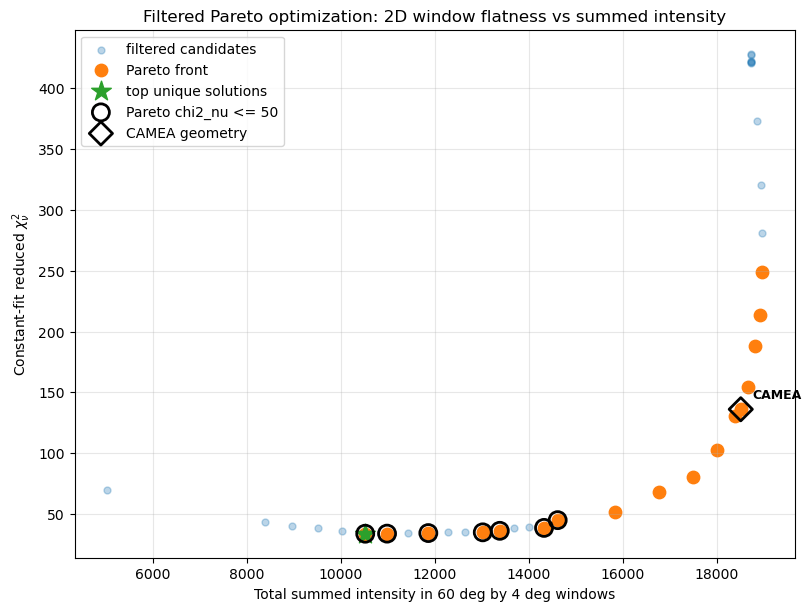

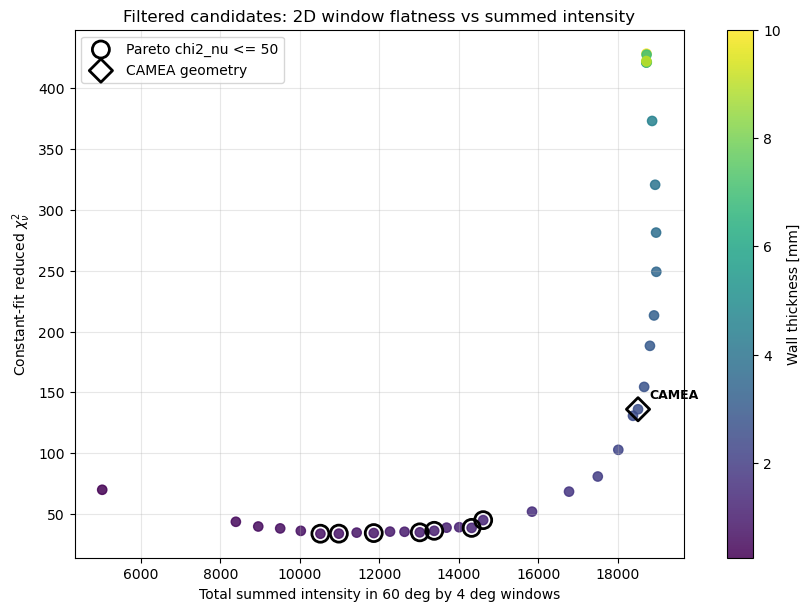

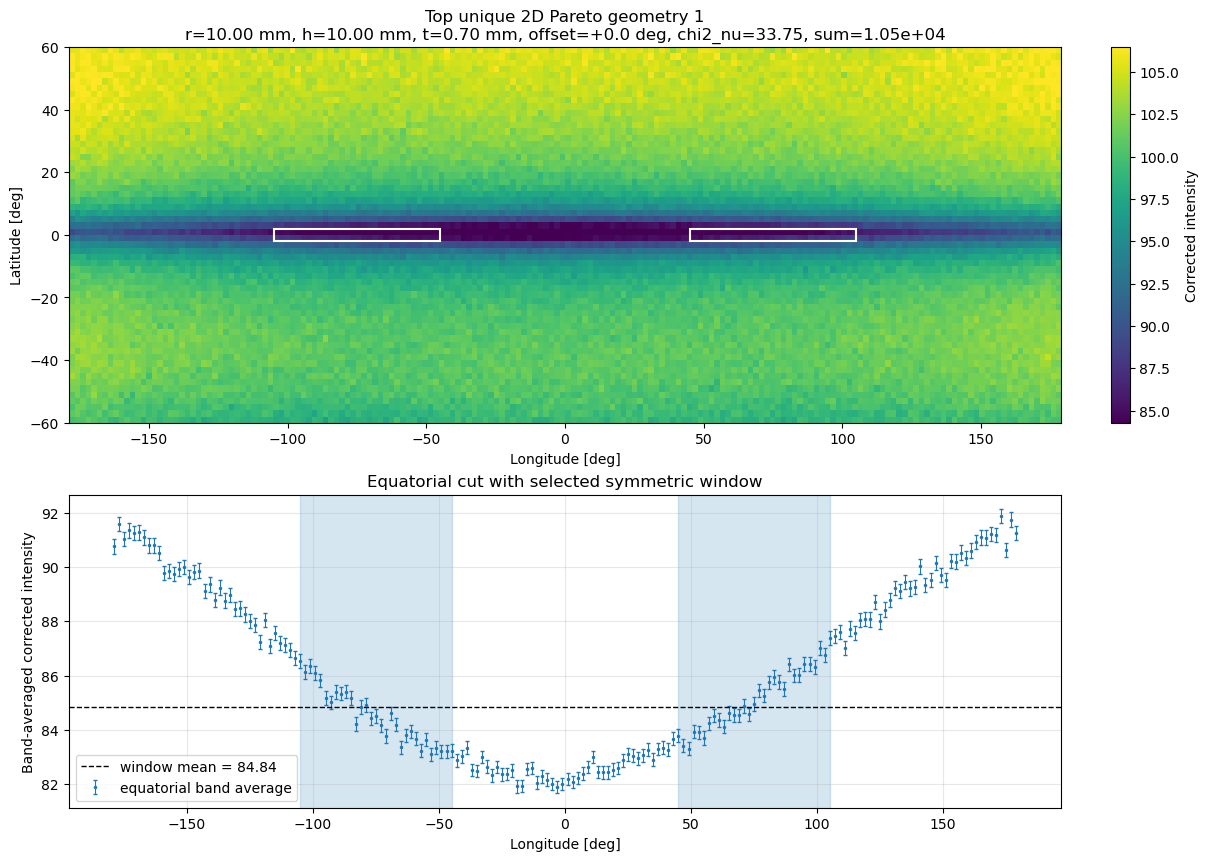

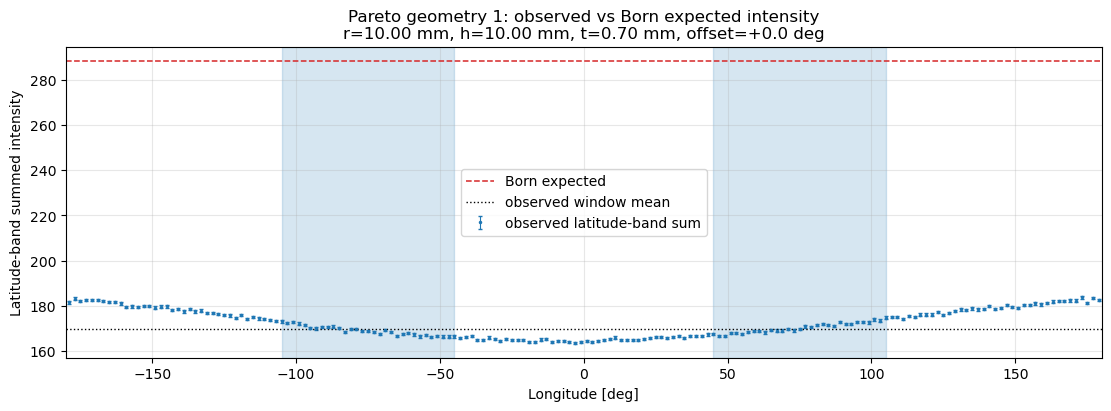

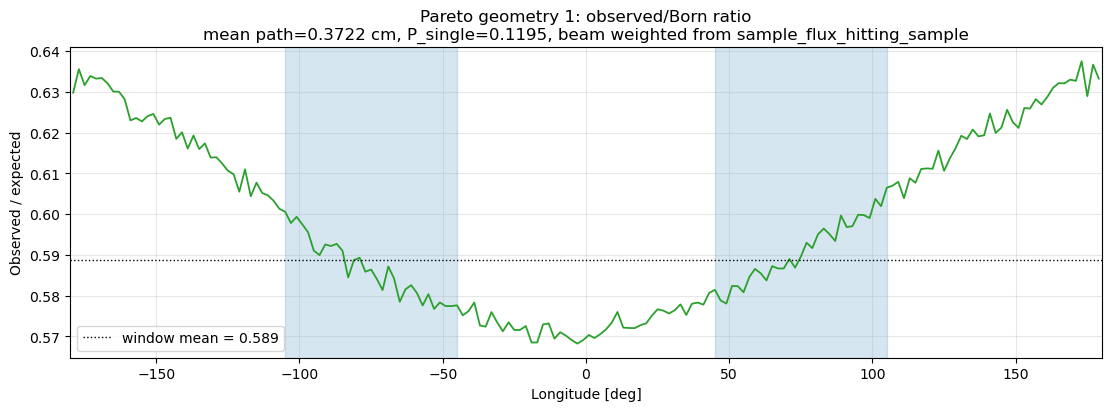

Geometry 1 Born profile summary: I_hit=1.24353e+07, V=0.804832 cm^3, mean_path=0.37217 cm, P_single=0.119519, path_method=beam weighted from sample_flux_hitting_sample, expected_window_mean=288.209, observed_window_mean=169.671, observed/Born=0.588707


In [56]:
# ============================================================
# Filtered Pareto front: 2D detector-window sum vs constant-fit chi2
# ============================================================

# This cell is self-contained so it can scan a different run folder from
# the profile-based Pareto cell above.

# ----------------------------
# 2D Pareto settings
# ----------------------------

psi_pareto_root = Path(
    '/Users/christian/Documents/Study/bachelor_project/geometry_optimization/PSI_instrument/scan_folder_h10mmfixed_5meV_2e9'
)

psi_monitor_name_candidates = (
    'sample_spherical_monitor_scattered',
    # 'sample_spherical_monitor',
    # 'cylinder_scattered',
)

psi_detector_window_center_deg = 75.0
psi_detector_center_offsets_deg = np.arange(0.0, 0.1, 4.0)
psi_detector_window_width_deg = 60.0
psi_detector_latitude_halfwidth_deg = 2.0

psi_beam_mask_lon_halfwidth_deg = 2.0 # mask direct beam within this longitude range around 0 deg
psi_beam_mask_lat_halfwidth_deg = 4.0 # mask direct beam within this latitude range around 0 deg
psi_mask_direct_beam = False

psi_s_tol_value = 0.0
psi_i_tol_value = 0.0
psi_min_total_window_intensity = 1e3 # value for CAMEA geometry was 1.85e4

# Wavelength filter in Angstrom. Use None to keep all wavelengths,
# or e.g. 4.0 / 5.0 to keep one wavelength.
# The notebook derives wavelength from SourceE/EI when no explicit wavelength
# parameter is present in mccode.sim.
psi_wavelength_filter_angstrom = 4.0
psi_wavelength_tolerance_angstrom = 0.2

# Plot only candidates with reduced chi-square at or below this value.
# Set to None to show all filtered candidates.
psi_plot_max_reduced_chi_square = None

# Mark and print Pareto-front candidates below this reduced chi-square cutoff.
psi_pareto_mark_max_reduced_chi_square = 50.0

psi_radius_bounds_mm = (9.0, 11.0)
psi_height_bounds_mm = (0.0, np.inf)
psi_thickness_bounds_mm = (0.0, np.inf)

# Optional reference run to mark on the 2D Pareto plot.
psi_camea_geometry_run_dir = psi_pareto_root / 'CAMEA_geometry'
psi_camea_geometry_offset_deg = 0.0

# Single-scattering expectation used for observed/expected deviation maps.
psi_sigma_inc_cm_inv = 0.367
psi_sigma_abs_cm_inv = psi_sigma_inc_cm_inv
psi_sigma_coh_cm_inv = 0.0
psi_sigma_total_cm_inv = psi_sigma_inc_cm_inv + psi_sigma_abs_cm_inv + psi_sigma_coh_cm_inv
psi_flux_monitor_candidates = ('sample_flux_hitting_sample', 'sample_flux_before')
# Use the sampled beam footprint when computing the Born mean path.
# This avoids counting lids or side-wall regions that the incoming beam does not illuminate.
psi_use_beam_weighted_born_path = True

# ----------------------------
# 2D Pareto helpers
# ----------------------------


def energy_mev_to_wavelength_angstrom(energy_mev):
    if energy_mev is None or energy_mev <= 0.0:
        return np.nan
    return np.sqrt(81.8042096 / energy_mev)


def parse_psi_geometry_from_mccode_sim(sim_file):

    params = {}
    pattern = re.compile(r'^\s*Param:\s*([A-Za-z0-9_]+)\s*=\s*([^,\s]+)')

    with sim_file.open('r') as f:
        for line in f:
            match = pattern.match(line)
            if not match:
                continue
            key = match.group(1).strip()
            raw_value = match.group(2).strip()
            try:
                params[key] = float(raw_value)
            except ValueError:
                pass

    radius_keys = ('sampleRadius', 'cylinder_radius')
    height_keys = ('sampleHeight', 'cylinder_height')
    thickness_keys = ('sampleThickness', 'thickness')
    wavelength_keys = ('wavelength', 'Wavelength', 'lambda', 'Lambda')
    energy_keys = ('SourceE', 'EI', 'E0', 'energy')

    def first_available(keys):
        for key in keys:
            if key in params:
                return params[key]
        raise ValueError(f'Missing one of {keys} in {sim_file}')

    wavelength_angstrom = np.nan
    wavelength_source = 'missing'

    for key in wavelength_keys:
        if key in params:
            wavelength_angstrom = params[key]
            wavelength_source = key
            break

    if not np.isfinite(wavelength_angstrom):
        for key in energy_keys:
            if key in params:
                wavelength_angstrom = energy_mev_to_wavelength_angstrom(params[key])
                wavelength_source = f'derived from {key}'
                break

    return {
        'outer_radius_mm': first_available(radius_keys) * 1000.0,
        'outer_height_mm': first_available(height_keys) * 1000.0,
        'wall_thickness_mm': first_available(thickness_keys) * 1000.0,
        'wavelength_angstrom': wavelength_angstrom,
        'wavelength_source': wavelength_source,
    }


def load_psi_monitor_from_run(run_dir):

    loaded = ms.load_data(str(run_dir))

    if not loaded:
        raise ValueError(f'No McStas data loaded from {run_dir}')

    for wanted in psi_monitor_name_candidates:
        for item in loaded:
            name = str(getattr(item, 'name', '') or '')
            component = str(getattr(item, 'component_name', '') or '')
            filename = str(getattr(item, 'filename', '') or '')
            if (
                wanted in name
                or wanted in component
                or wanted in filename
            ):
                return item

    names = [
        str(getattr(item, 'name', '') or getattr(item, 'component_name', '') or item)
        for item in loaded
    ]
    raise ValueError(
        f'None of {psi_monitor_name_candidates} found in {run_dir}. '
        f'Available records: {names}'
    )


def get_psi_corrected_heatmap_from_run(run_dir):

    sphere_mon = load_psi_monitor_from_run(run_dir)
    meta = sphere_mon.metadata

    H = np.array(sphere_mon.Intensity, copy=True)
    H_err = np.array(sphere_mon.Error, copy=True)

    if (
        hasattr(meta, 'dimension')
        and H.shape == (meta.dimension[0], meta.dimension[1])
    ):
        H = H.T
        H_err = H_err.T

    xmin, xmax, ymin, ymax = meta.limits

    lat_centers = np.linspace(
        ymin + 0.5 * (ymax - ymin) / H.shape[0],
        ymax - 0.5 * (ymax - ymin) / H.shape[0],
        H.shape[0],
    )

    lon_centers = np.linspace(
        xmin + 0.5 * (xmax - xmin) / H.shape[1],
        xmax - 0.5 * (xmax - xmin) / H.shape[1],
        H.shape[1],
    )

    cos_correction = np.cos(np.radians(lat_centers))[:, np.newaxis]
    safe_cos = np.where(np.abs(cos_correction) > 0, cos_correction, np.nan)

    H_corr = H / safe_cos
    H_err_corr = H_err / safe_cos

    if psi_mask_direct_beam:
        Lon, Lat = np.meshgrid(lon_centers, lat_centers)
        beam_center_mask = (
            (np.abs(Lon) <= psi_beam_mask_lon_halfwidth_deg)
            &
            (np.abs(Lat) <= psi_beam_mask_lat_halfwidth_deg)
        )
        H_corr = np.where(~beam_center_mask, H_corr, np.nan)
        H_err_corr = np.where(~beam_center_mask, H_err_corr, np.nan)

    return lon_centers, lat_centers, H_corr, H_err_corr


def pareto_front_indices(
    S_values,
    I_values,
    s_tol=0.05, # required fractional improvement in S
    i_tol=0.05, # required fractional improvement in intensity
):
    """
    Pareto front with tolerances.

    s_tol = required fractional improvement in S
    i_tol = required fractional improvement in intensity
    """

    S_values = np.asarray(S_values)
    I_values = np.asarray(I_values)

    n = len(S_values)

    is_pareto = np.ones(n, dtype=bool)

    for i in range(n):

        if not is_pareto[i]:
            continue

        better_S = (
            S_values
            <=
            S_values[i] * (1.0 - s_tol)
        )

        better_I = (
            I_values
            >=
            I_values[i] * (1.0 + i_tol)
        )

        dominates = better_S & better_I

        dominates[i] = False

        if np.any(dominates):
            is_pareto[i] = False

    return np.where(is_pareto)[0]


def psi_sample_material_volume_cm3_from_solution(solution):
    R = solution['outer_radius_mm'] / 10.0
    H = solution['outer_height_mm'] / 10.0
    t = solution['wall_thickness_mm'] / 10.0
    r = R - t
    H_inner = H - 2.0 * t
    if r <= 0.0 or H_inner < 0.0:
        return np.nan
    return np.pi * R**2 * H - np.pi * r**2 * H_inner


def psi_projected_area_cm2_from_solution(solution):
    R = solution['outer_radius_mm'] / 10.0
    H = solution['outer_height_mm'] / 10.0
    return 2.0 * R * H


def psi_mean_path_length_cm_from_solution(solution):
    return psi_sample_material_volume_cm3_from_solution(solution) / psi_projected_area_cm2_from_solution(solution)


def psi_material_path_map_cm(x_centers_cm, y_centers_cm, solution):
    x = np.asarray(x_centers_cm, dtype=float)
    y = np.asarray(y_centers_cm, dtype=float)

    R = solution['outer_radius_mm'] / 10.0
    H = solution['outer_height_mm'] / 10.0
    t = solution['wall_thickness_mm'] / 10.0
    r = max(R - t, 0.0)

    outer_chord = np.zeros_like(x, dtype=float)
    outer_mask = np.abs(x) <= R
    outer_chord[outer_mask] = 2.0 * np.sqrt(np.maximum(R**2 - x[outer_mask]**2, 0.0))

    inner_chord = np.zeros_like(x, dtype=float)
    inner_mask = np.abs(x) <= r
    inner_chord[inner_mask] = 2.0 * np.sqrt(np.maximum(r**2 - x[inner_mask]**2, 0.0))

    side_path = outer_chord - inner_chord
    in_outer_height = np.abs(y) <= 0.5 * H
    in_lid = (np.abs(y) >= 0.5 * H - t) & (np.abs(y) <= 0.5 * H) if t > 0.0 else np.zeros_like(y, dtype=bool)
    in_side_wall = in_outer_height & ~in_lid

    path = np.outer(in_side_wall.astype(float), side_path)
    path += np.outer(in_lid.astype(float), outer_chord)
    return path


def psi_monitor_xy_image_from_run(run_dir, name_candidates):
    loaded = ms.load_data(str(run_dir))
    for wanted in name_candidates:
        for item in loaded:
            name = str(getattr(item, 'name', '') or '')
            component = str(getattr(item, 'component_name', '') or '')
            filename = str(getattr(item, 'filename', '') or '')
            if wanted in name or wanted in component or wanted in filename:
                image = np.asarray(item.Intensity, dtype=float).copy()
                meta = item.metadata
                if hasattr(meta, 'dimension') and image.shape == (meta.dimension[0], meta.dimension[1]):
                    image = image.T
                xmin, xmax, ymin, ymax = meta.limits
                y_centers = np.linspace(
                    ymin + 0.5 * (ymax - ymin) / image.shape[0],
                    ymax - 0.5 * (ymax - ymin) / image.shape[0],
                    image.shape[0],
                )
                x_centers = np.linspace(
                    xmin + 0.5 * (xmax - xmin) / image.shape[1],
                    xmax - 0.5 * (xmax - xmin) / image.shape[1],
                    image.shape[1],
                )
                return x_centers, y_centers, image, wanted
    names = [str(getattr(item, 'name', '') or getattr(item, 'component_name', '') or item) for item in loaded]
    raise ValueError(f'None of {name_candidates} found in {run_dir}. Available records: {names}')


def psi_beam_weighted_mean_path_length_cm_from_solution(solution):
    x_centers, y_centers, weights, monitor_name = psi_monitor_xy_image_from_run(
        Path(solution['run_dir']),
        psi_flux_monitor_candidates,
    )
    path = psi_material_path_map_cm(x_centers, y_centers, solution)
    valid = np.isfinite(weights) & np.isfinite(path) & (weights > 0.0)
    total_weight = np.nansum(weights[valid])
    if total_weight <= 0.0:
        return np.nan, monitor_name
    return float(np.nansum(weights[valid] * path[valid]) / total_weight), monitor_name


def psi_born_mean_path_length_cm_from_solution(solution):
    if psi_use_beam_weighted_born_path:
        mean_path, monitor_name = psi_beam_weighted_mean_path_length_cm_from_solution(solution)
        if np.isfinite(mean_path):
            return mean_path, f'beam weighted from {monitor_name}'
    return psi_mean_path_length_cm_from_solution(solution), 'full volume / projected area'


def psi_single_scatter_probability_from_path_length(mean_path):
    total_interaction = 1.0 - np.exp(-psi_sigma_total_cm_inv * mean_path)
    return total_interaction * psi_sigma_inc_cm_inv / psi_sigma_total_cm_inv


def psi_record_total_from_run(run_dir, name_candidates):
    loaded = ms.load_data(str(run_dir))
    for wanted in name_candidates:
        for item in loaded:
            name = str(getattr(item, 'name', '') or '')
            component = str(getattr(item, 'component_name', '') or '')
            filename = str(getattr(item, 'filename', '') or '')
            if wanted in name or wanted in component or wanted in filename:
                return float(np.nansum(np.asarray(item.Intensity, dtype=float)))
    names = [str(getattr(item, 'name', '') or getattr(item, 'component_name', '') or item) for item in loaded]
    raise ValueError(f'None of {name_candidates} found in {run_dir}. Available records: {names}')


def psi_corrected_single_scattering_expected_map(solution, lon, lat):
    run_dir = Path(solution['run_dir'])
    hit_intensity = psi_record_total_from_run(run_dir, psi_flux_monitor_candidates)
    mean_path, path_method = psi_born_mean_path_length_cm_from_solution(solution)
    probability = psi_single_scatter_probability_from_path_length(mean_path)

    if lon.size < 2 or lat.size < 2:
        raise ValueError('Need at least two longitude and latitude bins for solid-angle estimate')

    dlon_rad = np.deg2rad(np.nanmedian(np.diff(lon)))
    dlat_rad = np.deg2rad(np.nanmedian(np.diff(lat)))
    lat_rad = np.deg2rad(lat)
    lat_low = lat_rad - 0.5 * dlat_rad
    lat_high = lat_rad + 0.5 * dlat_rad
    solid_angle_by_lat = dlon_rad * (np.sin(lat_high) - np.sin(lat_low))
    cos_lat = np.cos(lat_rad)
    corrected_solid_angle_by_lat = solid_angle_by_lat / np.where(np.abs(cos_lat) > 0.0, cos_lat, np.nan)

    expected_by_lat = hit_intensity * probability * corrected_solid_angle_by_lat / (4.0 * np.pi)
    expected_map = np.repeat(expected_by_lat[:, np.newaxis], lon.size, axis=1)
    return expected_map, {
        'hit_intensity': hit_intensity,
        'probability': probability,
        'mean_path_cm': mean_path,
        'path_method': path_method,
        'full_volume_mean_path_cm': psi_mean_path_length_cm_from_solution(solution),
        'material_volume_cm3': psi_sample_material_volume_cm3_from_solution(solution),
    }


def psi_window_2d_metrics_from_run(run_dir, center_deg):

    lon, lat, H, H_err = get_psi_corrected_heatmap_from_run(run_dir)

    half_lon = psi_detector_window_width_deg / 2.0
    half_lat = psi_detector_latitude_halfwidth_deg

    pos_min = center_deg - half_lon
    pos_max = center_deg + half_lon
    neg_min = -pos_max
    neg_max = -pos_min

    Lon, Lat = np.meshgrid(lon, lat)

    window_mask = (
        (np.abs(Lat) <= half_lat)
        &
        (
            ((Lon >= pos_min) & (Lon <= pos_max))
            |
            ((Lon >= neg_min) & (Lon <= neg_max))
        )
    )

    y_all = H[window_mask]
    err_all = H_err[window_mask]

    valid_intensity = np.isfinite(y_all) & (y_all > 0.0)
    total_window_intensity = np.nansum(y_all[valid_intensity])

    valid_fit = (
        valid_intensity
        &
        np.isfinite(err_all)
        &
        (err_all > 0.0)
    )

    y_fit = y_all[valid_fit]
    err_fit = err_all[valid_fit]

    if y_fit.size < 2:
        return None

    window_fit_mean = np.mean(y_fit)
    window_fit_min = np.min(y_fit)
    window_fit_max = np.max(y_fit)
    window_peak_to_peak = window_fit_max - window_fit_min
    window_max_abs_deviation = np.max(np.abs(y_fit - window_fit_mean))
    if window_fit_mean > 0.0:
        window_peak_to_peak_relative = window_peak_to_peak / window_fit_mean
        window_max_abs_deviation_relative = window_max_abs_deviation / window_fit_mean
    else:
        window_peak_to_peak_relative = np.nan
        window_max_abs_deviation_relative = np.nan

    weights = 1.0 / err_fit**2
    constant_fit = np.sum(weights * y_fit) / np.sum(weights)
    chi2 = np.sum(((y_fit - constant_fit) / err_fit)**2)
    reduced_chi_square = chi2 / (y_fit.size - 1)

    if not np.isfinite(reduced_chi_square):
        return None

    return {
        'center_deg': center_deg,
        'pos_min': pos_min,
        'pos_max': pos_max,
        'neg_min': neg_min,
        'neg_max': neg_max,
        'constant_fit': constant_fit,
        'reduced_chi_square_2d': reduced_chi_square,
        'total_window_intensity': total_window_intensity,
        'window_fit_mean': window_fit_mean,
        'window_peak_to_peak_relative': window_peak_to_peak_relative,
        'window_max_abs_deviation': window_max_abs_deviation,
        'window_max_abs_deviation_relative': window_max_abs_deviation_relative,
        'n_window_pixels': int(np.sum(window_mask)),
        'n_fit_pixels': int(y_fit.size),
        'S': reduced_chi_square,
    }


# ----------------------------
# Parse PSI runs
# ----------------------------

psi_sim_files = sorted(psi_pareto_root.glob('**/mccode.sim'))
psi_records_2d_unfiltered = []

for sim_file in psi_sim_files:

    run_dir = sim_file.parent

    try:
        geom = parse_psi_geometry_from_mccode_sim(sim_file)
        # Load once here to skip broken runs before scanning offsets.
        get_psi_corrected_heatmap_from_run(run_dir)
    except Exception:
        continue

    for offset_deg in psi_detector_center_offsets_deg:

        center_deg = psi_detector_window_center_deg + offset_deg
        metrics = psi_window_2d_metrics_from_run(run_dir, center_deg)

        if metrics is None:
            continue

        metrics.update({
            'offset_deg': offset_deg,
            'run_dir': str(run_dir),
            'geometry_dir': str(run_dir.parent),
            **geom,
        })

        psi_records_2d_unfiltered.append(metrics)


psi_records_2d = [
    r for r in psi_records_2d_unfiltered
    if (
        r['total_window_intensity'] >= psi_min_total_window_intensity
        and (
            psi_wavelength_filter_angstrom is None
            or (
                np.isfinite(r['wavelength_angstrom'])
                and abs(r['wavelength_angstrom'] - psi_wavelength_filter_angstrom)
                <= psi_wavelength_tolerance_angstrom
            )
        )
        and psi_radius_bounds_mm[0] <= r['outer_radius_mm'] <= psi_radius_bounds_mm[1]
        and psi_height_bounds_mm[0] <= r['outer_height_mm'] <= psi_height_bounds_mm[1]
        and psi_thickness_bounds_mm[0] <= r['wall_thickness_mm'] <= psi_thickness_bounds_mm[1]
    )
]

psi_camea_geometry_record = None
if psi_camea_geometry_run_dir is not None and Path(psi_camea_geometry_run_dir).exists():
    try:
        _camea_run_dir = Path(psi_camea_geometry_run_dir)
        _camea_geom = parse_psi_geometry_from_mccode_sim(_camea_run_dir / 'mccode.sim')
        _camea_center = psi_detector_window_center_deg + psi_camea_geometry_offset_deg
        psi_camea_geometry_record = psi_window_2d_metrics_from_run(_camea_run_dir, _camea_center)
        if psi_camea_geometry_record is not None:
            psi_camea_geometry_record.update({
                'offset_deg': psi_camea_geometry_offset_deg,
                'run_dir': str(_camea_run_dir),
                'geometry_dir': str(_camea_run_dir),
                **_camea_geom,
            })
    except Exception as exc:
        print(f'CAMEA geometry marker skipped: {exc}')

print(f'2D Pareto root: {psi_pareto_root}')
print(f'Found mccode.sim files: {len(psi_sim_files)}')
if psi_records_2d_unfiltered:
    wavelengths_found = sorted({
        round(r['wavelength_angstrom'], 3)
        for r in psi_records_2d_unfiltered
        if np.isfinite(r['wavelength_angstrom'])
    })
else:
    wavelengths_found = []

print(f'2D candidate windows before filtering: {len(psi_records_2d_unfiltered)}')
print(f'2D candidate windows after filtering:  {len(psi_records_2d)}')
print(f'Wavelengths found [Angstrom]: {wavelengths_found}')

if psi_records_2d_unfiltered:
    _filter_arrays = {
        'total_window_intensity': np.array([r['total_window_intensity'] for r in psi_records_2d_unfiltered], dtype=float),
        'wavelength_angstrom': np.array([r['wavelength_angstrom'] for r in psi_records_2d_unfiltered], dtype=float),
        'outer_radius_mm': np.array([r['outer_radius_mm'] for r in psi_records_2d_unfiltered], dtype=float),
        'outer_height_mm': np.array([r['outer_height_mm'] for r in psi_records_2d_unfiltered], dtype=float),
        'wall_thickness_mm': np.array([r['wall_thickness_mm'] for r in psi_records_2d_unfiltered], dtype=float),
        'reduced_chi_square_2d': np.array([r['reduced_chi_square_2d'] for r in psi_records_2d_unfiltered], dtype=float),
    }
    _filter_masks = {
        'intensity': _filter_arrays['total_window_intensity'] >= psi_min_total_window_intensity,
        'wavelength': (
            psi_wavelength_filter_angstrom is None
            or (
                np.isfinite(_filter_arrays['wavelength_angstrom'])
                & (np.abs(_filter_arrays['wavelength_angstrom'] - psi_wavelength_filter_angstrom) <= psi_wavelength_tolerance_angstrom)
            )
        ),
        'radius': (psi_radius_bounds_mm[0] <= _filter_arrays['outer_radius_mm']) & (_filter_arrays['outer_radius_mm'] <= psi_radius_bounds_mm[1]),
        'height': (psi_height_bounds_mm[0] <= _filter_arrays['outer_height_mm']) & (_filter_arrays['outer_height_mm'] <= psi_height_bounds_mm[1]),
        'thickness': (psi_thickness_bounds_mm[0] <= _filter_arrays['wall_thickness_mm']) & (_filter_arrays['wall_thickness_mm'] <= psi_thickness_bounds_mm[1]),
    }
    print('2D filter diagnostics before filtering:')
    for _key, _values in _filter_arrays.items():
        print(f"  {_key:<24} min={np.nanmin(_values):.6g}, max={np.nanmax(_values):.6g}")
    _cumulative = np.ones(len(psi_records_2d_unfiltered), dtype=bool)
    for _name, _mask in _filter_masks.items():
        _mask = np.asarray(_mask, dtype=bool)
        _cumulative &= _mask
        print(
            f"  filter {_name:<10}: pass={np.count_nonzero(_mask):4d}, "
            f"fail={np.count_nonzero(~_mask):4d}, cumulative={np.count_nonzero(_cumulative):4d}"
        )
print(
    'Wavelength filter [Angstrom]: '
    f'{psi_wavelength_filter_angstrom} '
    f'+/- {psi_wavelength_tolerance_angstrom}'
)
print(
    '2D window: '
    f'center={psi_detector_window_center_deg:g} deg, '
    f'offsets=[{psi_detector_center_offsets_deg.min():g}, {psi_detector_center_offsets_deg.max():g}] deg, '
    f'width={psi_detector_window_width_deg:g} deg, '
    f'latitude half-width={psi_detector_latitude_halfwidth_deg:g} deg'
)

if not psi_records_2d:

    print('No valid 2D-window candidates found.')

else:

    S_2d = np.array([r['reduced_chi_square_2d'] for r in psi_records_2d])
    I_2d = np.array([r['total_window_intensity'] for r in psi_records_2d])

    pareto_idx_2d = pareto_front_indices(
        S_2d,
        I_2d,
        s_tol=psi_s_tol_value,
        i_tol=psi_i_tol_value,
    )

    pareto_records_2d = sorted(
        [psi_records_2d[i] for i in pareto_idx_2d],
        key=lambda r: r['reduced_chi_square_2d'],
    )

    unique_pareto_2d_by_radius_height = {}

    for r in pareto_records_2d:

        radius_height_key = (
            round(r['outer_radius_mm'], 6),
            round(r['outer_height_mm'], 6),
        )

        current = unique_pareto_2d_by_radius_height.get(radius_height_key)

        if (
            current is None
            or
            (
                r['reduced_chi_square_2d'],
                -r['total_window_intensity'],
            )
            <
            (
                current['reduced_chi_square_2d'],
                -current['total_window_intensity'],
            )
        ):
            unique_pareto_2d_by_radius_height[radius_height_key] = r

    top_unique_2d = sorted(
        unique_pareto_2d_by_radius_height.values(),
        key=lambda r: r['reduced_chi_square_2d'],
    )[:10]



    def psi_observed_expected_profile_window_summary(solution):
        lon, lat, H, H_err = get_psi_corrected_heatmap_from_run(Path(solution['run_dir']))
        expected_map, expected_info = psi_corrected_single_scattering_expected_map(solution, lon, lat)

        band_mask = np.abs(lat) <= psi_detector_latitude_halfwidth_deg
        observed_profile = np.nansum(H[band_mask, :], axis=0)
        expected_profile = np.nansum(expected_map[band_mask, :], axis=0)

        window_mask = (
            ((lon >= solution['pos_min']) & (lon <= solution['pos_max']))
            |
            ((lon >= solution['neg_min']) & (lon <= solution['neg_max']))
        )
        valid = (
            np.isfinite(observed_profile)
            & np.isfinite(expected_profile)
            & (expected_profile > 0.0)
            & (observed_profile != 0.0)
        )

        ratio_values = np.full_like(observed_profile, np.nan, dtype=float)
        ratio_values[valid] = observed_profile[valid] / expected_profile[valid]

        return {
            'observed_window_mean': np.nanmean(observed_profile[window_mask]),
            'expected_window_mean': np.nanmean(expected_profile[window_mask]),
            'observed_expected_ratio': np.nanmean(ratio_values[window_mask]),
            'expected_info': expected_info,
        }

    print(f'2D-window Pareto front size: {len(pareto_records_2d)}')
    print('\nTop 10 unique 2D-window Pareto geometries:\n')

    for i, r in enumerate(top_unique_2d, start=1):
        observed_expected_summary = psi_observed_expected_profile_window_summary(r)
        print(
            f"{i}. "
            f"r={r['outer_radius_mm']:.2f} mm, "
            f"h={r['outer_height_mm']:.2f} mm, "
            f"t={r['wall_thickness_mm']:.2f} mm, "
            f"lambda={r['wavelength_angstrom']:.3g} A, "
            f"offset={r['offset_deg']:+.1f} deg, "
            f"chi2_nu={r['reduced_chi_square_2d']:.5g}, "
            f"sum={r['total_window_intensity']:.3e}, "
            f"pixels={r['n_fit_pixels']}"
        )
        print(
            f"   peak-to-peak/mean={r['window_peak_to_peak_relative']:.6g}, "
            f"max abs deviation/mean={r['window_max_abs_deviation_relative']:.6g}, "
            f"max abs deviation={r['window_max_abs_deviation']:.6g}, "
            f"observed/Born={observed_expected_summary['observed_expected_ratio']:.6g}"
        )
        print(f"   path={r['run_dir']}")

    pareto_chi2_cutoff_records_2d = sorted(
        [
            r for r in pareto_records_2d
            if r['reduced_chi_square_2d'] <= psi_pareto_mark_max_reduced_chi_square
        ],
        key=lambda r: r['total_window_intensity'],
    )

    print(
        f"\nPareto-front geometries with chi2_nu <= "
        f"{psi_pareto_mark_max_reduced_chi_square:g}:\n"
    )
    if not pareto_chi2_cutoff_records_2d:
        print('   none')
    for i, r in enumerate(pareto_chi2_cutoff_records_2d, start=1):
        observed_expected_summary = psi_observed_expected_profile_window_summary(r)
        print(
            f"{i}. "
            f"r={r['outer_radius_mm']:.2f} mm, "
            f"h={r['outer_height_mm']:.2f} mm, "
            f"t={r['wall_thickness_mm']:.2f} mm, "
            f"lambda={r['wavelength_angstrom']:.3g} A, "
            f"offset={r['offset_deg']:+.1f} deg, "
            f"chi2_nu={r['reduced_chi_square_2d']:.5g}, "
            f"sum={r['total_window_intensity']:.3e}, "
            f"pixels={r['n_fit_pixels']}"
        )
        print(
            f"   peak-to-peak/mean={r['window_peak_to_peak_relative']:.6g}, "
            f"max abs deviation/mean={r['window_max_abs_deviation_relative']:.6g}, "
            f"max abs deviation={r['window_max_abs_deviation']:.6g}, "
            f"observed/Born={observed_expected_summary['observed_expected_ratio']:.6g}"
        )
        print(f"   path={r['run_dir']}")

    if psi_plot_max_reduced_chi_square is None:
        plot_records_2d = psi_records_2d
        plot_pareto_records_2d = pareto_records_2d
        plot_top_unique_2d = top_unique_2d
    else:
        plot_records_2d = [
            r for r in psi_records_2d
            if r['reduced_chi_square_2d'] <= psi_plot_max_reduced_chi_square
        ]
        plot_pareto_records_2d = [
            r for r in pareto_records_2d
            if r['reduced_chi_square_2d'] <= psi_plot_max_reduced_chi_square
        ]
        plot_top_unique_2d = [
            r for r in top_unique_2d
            if r['reduced_chi_square_2d'] <= psi_plot_max_reduced_chi_square
        ]

    plot_pareto_chi2_cutoff_records_2d = [
        r for r in plot_pareto_records_2d
        if r['reduced_chi_square_2d'] <= psi_pareto_mark_max_reduced_chi_square
    ]

    print(
        f'2D plot candidates shown: {len(plot_records_2d)} / {len(psi_records_2d)}'
    )
    if psi_camea_geometry_record is not None:
        camea_observed_expected_summary = psi_observed_expected_profile_window_summary(psi_camea_geometry_record)
        print(
            'CAMEA geometry marker: '
            f"r={psi_camea_geometry_record['outer_radius_mm']:.2f} mm, "
            f"h={psi_camea_geometry_record['outer_height_mm']:.2f} mm, "
            f"t={psi_camea_geometry_record['wall_thickness_mm']:.2f} mm, "
            f"lambda={psi_camea_geometry_record['wavelength_angstrom']:.3g} A, "
            f"offset={psi_camea_geometry_record['offset_deg']:+.1f} deg, "
            f"chi2_nu={psi_camea_geometry_record['reduced_chi_square_2d']:.5g}, "
            f"sum={psi_camea_geometry_record['total_window_intensity']:.3e}, "
            f"pixels={psi_camea_geometry_record['n_fit_pixels']}"
        )
        print(
            f"   peak-to-peak/mean={psi_camea_geometry_record['window_peak_to_peak_relative']:.6g}, "
            f"max abs deviation/mean={psi_camea_geometry_record['window_max_abs_deviation_relative']:.6g}, "
            f"max abs deviation={psi_camea_geometry_record['window_max_abs_deviation']:.6g}, "
            f"observed/Born={camea_observed_expected_summary['observed_expected_ratio']:.6g}"
        )
        print(f"   path={psi_camea_geometry_record['run_dir']}")

    fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)

    ax.scatter(
        [r['total_window_intensity'] for r in plot_records_2d],
        [r['reduced_chi_square_2d'] for r in plot_records_2d],
        s=25,
        alpha=0.3,
        label='filtered candidates',
    )

    ax.scatter(
        [r['total_window_intensity'] for r in plot_pareto_records_2d],
        [r['reduced_chi_square_2d'] for r in plot_pareto_records_2d],
        s=80,
        label='Pareto front',
    )

    ax.scatter(
        [r['total_window_intensity'] for r in plot_top_unique_2d],
        [r['reduced_chi_square_2d'] for r in plot_top_unique_2d],
        marker='o',
        s=170,
        facecolor='none',
        edgecolor='black',
        linewidth=2.0,
        label='top unique solutions',
    )

    if plot_pareto_chi2_cutoff_records_2d:
        ax.scatter(
            [r['total_window_intensity'] for r in plot_pareto_chi2_cutoff_records_2d],
            [r['reduced_chi_square_2d'] for r in plot_pareto_chi2_cutoff_records_2d],
            marker='o',
            s=150,
            facecolor='none',
            edgecolor='black',
            linewidth=2.0,
            label=(
                'Pareto chi2_nu <= '
                f'{psi_pareto_mark_max_reduced_chi_square:g}'
            ),
            zorder=7,
        )

    if psi_camea_geometry_record is not None:
        ax.scatter(
            [psi_camea_geometry_record['total_window_intensity']],
            [psi_camea_geometry_record['reduced_chi_square_2d']],
            marker='D',
            s=140,
            facecolor='none',
            edgecolor='black',
            linewidth=2.0,
            label='CAMEA geometry',
            zorder=6,
        )
        ax.annotate(
            'CAMEA',
            (
                psi_camea_geometry_record['total_window_intensity'],
                psi_camea_geometry_record['reduced_chi_square_2d'],
            ),
            xytext=(8, 8),
            textcoords='offset points',
            fontsize=9,
            weight='bold',
        )

    ax.set_xlabel(
        f'Total summed intensity in {psi_detector_window_width_deg:g} deg '
        f'by {2.0 * psi_detector_latitude_halfwidth_deg:g} deg windows'
    )
    ax.set_ylabel(r'Constant-fit reduced $\chi^2_\nu$')
    title = 'Filtered Pareto optimization: 2D window flatness vs summed intensity'
    if psi_plot_max_reduced_chi_square is not None:
        title += f'\nshown: $\\chi^2_\\nu$ <= {psi_plot_max_reduced_chi_square:g}'
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend()

    plt.show()


    fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)

    thickness_scatter = ax.scatter(
        [r['total_window_intensity'] for r in plot_records_2d],
        [r['reduced_chi_square_2d'] for r in plot_records_2d],
        c=[r['wall_thickness_mm'] for r in plot_records_2d],
        s=45,
        alpha=0.85,
        cmap='viridis',
    )
    colorbar = fig.colorbar(thickness_scatter, ax=ax)
    colorbar.set_label('Wall thickness [mm]')

    if plot_pareto_chi2_cutoff_records_2d:
        ax.scatter(
            [r['total_window_intensity'] for r in plot_pareto_chi2_cutoff_records_2d],
            [r['reduced_chi_square_2d'] for r in plot_pareto_chi2_cutoff_records_2d],
            marker='o',
            s=150,
            facecolor='none',
            edgecolor='black',
            linewidth=2.0,
            label=(
                'Pareto chi2_nu <= '
                f'{psi_pareto_mark_max_reduced_chi_square:g}'
            ),
            zorder=7,
        )

    if psi_camea_geometry_record is not None:
        ax.scatter(
            [psi_camea_geometry_record['total_window_intensity']],
            [psi_camea_geometry_record['reduced_chi_square_2d']],
            marker='D',
            s=140,
            facecolor='none',
            edgecolor='black',
            linewidth=2.0,
            label='CAMEA geometry',
            zorder=6,
        )
        ax.annotate(
            'CAMEA',
            (
                psi_camea_geometry_record['total_window_intensity'],
                psi_camea_geometry_record['reduced_chi_square_2d'],
            ),
            xytext=(8, 8),
            textcoords='offset points',
            fontsize=9,
            weight='bold',
        )

    if plot_pareto_chi2_cutoff_records_2d or psi_camea_geometry_record is not None:
        ax.legend()

    ax.set_xlabel(
        f'Total summed intensity in {psi_detector_window_width_deg:g} deg '
        f'by {2.0 * psi_detector_latitude_halfwidth_deg:g} deg windows'
    )
    ax.set_ylabel(r'Constant-fit reduced $\chi^2_\nu$')
    thickness_title = 'Filtered candidates: 2D window flatness vs summed intensity'
    if psi_plot_max_reduced_chi_square is not None:
        thickness_title += f'\nshown: $\\chi^2_\\nu$ <= {psi_plot_max_reduced_chi_square:g}'
    ax.set_title(thickness_title)
    ax.grid(True, alpha=0.3)

    plt.show()


    def plot_2d_pareto_geometry(solution, index):
        lon, lat, H, H_err = get_psi_corrected_heatmap_from_run(Path(solution['run_dir']))

        band_mask = np.abs(lat) <= psi_detector_latitude_halfwidth_deg
        profile = np.nanmean(H[band_mask, :], axis=0)
        if H_err is not None:
            profile_err = np.sqrt(np.nansum(H_err[band_mask, :] ** 2, axis=0)) / max(np.count_nonzero(band_mask), 1)
        else:
            profile_err = None

        pos_min = solution['pos_min']
        pos_max = solution['pos_max']
        neg_min = solution['neg_min']
        neg_max = solution['neg_max']
        window_mask = ((lon >= pos_min) & (lon <= pos_max)) | ((lon >= neg_min) & (lon <= neg_max))
        window_mean = np.nanmean(profile[window_mask])

        fig, axes = plt.subplots(
            2,
            1,
            figsize=(12, 8.5),
            gridspec_kw={'height_ratios': [1.2, 1.0]},
            constrained_layout=True,
        )

        display_lat_min, display_lat_max = -60.0, 60.0
        display_lat_mask = (lat >= display_lat_min) & (lat <= display_lat_max)
        H_display = H[display_lat_mask, :]
        vmin, vmax = np.nanpercentile(H_display, [1.0, 99.5])
        im = axes[0].imshow(
            H_display,
            origin='lower',
            aspect='auto',
            extent=[lon.min(), lon.max(), display_lat_min, display_lat_max],
            interpolation='nearest',
            cmap='viridis',
            vmin=vmin,
            vmax=vmax,
        )
        # axes[0].axhline(0.0, color='white', linestyle=':', linewidth=1.0, alpha=0.9)
        # axes[0].axhline(psi_detector_latitude_halfwidth_deg, color='white', linestyle=':', linewidth=0.9, alpha=0.9)
        # axes[0].axhline(-psi_detector_latitude_halfwidth_deg, color='white', linestyle=':', linewidth=0.9, alpha=0.9)
        for xmin_win, xmax_win in [(pos_min, pos_max), (neg_min, neg_max)]:
            axes[0].add_patch(Rectangle(
                (xmin_win, -psi_detector_latitude_halfwidth_deg),
                xmax_win - xmin_win,
                2.0 * psi_detector_latitude_halfwidth_deg,
                fill=False,
                edgecolor='white',
                linewidth=1.5,
            ))
        axes[0].set_title(
            f'Top unique 2D Pareto geometry {index}\n'
            f"r={solution['outer_radius_mm']:.2f} mm, "
            f"h={solution['outer_height_mm']:.2f} mm, "
            f"t={solution['wall_thickness_mm']:.2f} mm, "
            f"offset={solution['offset_deg']:+.1f} deg, "
            f"chi2_nu={solution['reduced_chi_square_2d']:.4g}, "
            f"sum={solution['total_window_intensity']:.3g}"
        )
        axes[0].set_xlabel('Longitude [deg]')
        axes[0].set_ylabel('Latitude [deg]')
        fig.colorbar(im, ax=axes[0], label='Corrected intensity')

        valid = np.isfinite(profile)
        if profile_err is not None:
            axes[1].errorbar(
                lon[valid],
                profile[valid],
                yerr=profile_err[valid],
                fmt='.',
                markersize=3,
                linewidth=0.8,
                capsize=1.5,
                label='equatorial band average',
            )
        else:
            axes[1].plot(lon[valid], profile[valid], '.', markersize=3, label='equatorial band average')
        axes[1].axvspan(pos_min, pos_max, alpha=0.18, color='tab:blue')
        axes[1].axvspan(neg_min, neg_max, alpha=0.18, color='tab:blue')
        axes[1].axhline(window_mean, color='black', linestyle='--', linewidth=1.0, label=f'window mean = {window_mean:.4g}')
        axes[1].set_title('Equatorial cut with selected symmetric window')
        axes[1].set_xlabel('Longitude [deg]')
        axes[1].set_ylabel('Band-averaged corrected intensity')
        axes[1].grid(True, alpha=0.3)
        axes[1].legend(loc='best')

        plt.show()

    for i, solution in enumerate(top_unique_2d[:5], start=1):
        plot_2d_pareto_geometry(solution, i)

    def plot_observed_vs_born_profile(solution, index):
        lon, lat, H, H_err = get_psi_corrected_heatmap_from_run(Path(solution['run_dir']))
        expected_map, expected_info = psi_corrected_single_scattering_expected_map(solution, lon, lat)

        band_mask = np.abs(lat) <= psi_detector_latitude_halfwidth_deg
        observed_profile = np.nansum(H[band_mask, :], axis=0)
        expected_profile = np.nansum(expected_map[band_mask, :], axis=0)
        if H_err is not None:
            observed_profile_err = np.sqrt(np.nansum(H_err[band_mask, :] ** 2, axis=0))
        else:
            observed_profile_err = None

        pos_min = solution['pos_min']
        pos_max = solution['pos_max']
        neg_min = solution['neg_min']
        neg_max = solution['neg_max']
        window_mask = ((lon >= pos_min) & (lon <= pos_max)) | ((lon >= neg_min) & (lon <= neg_max))

        valid = np.isfinite(observed_profile) & np.isfinite(expected_profile) & (expected_profile > 0.0) & (observed_profile != 0.0)
        observed_window_mean = np.nanmean(observed_profile[window_mask])
        expected_window_mean = np.nanmean(expected_profile[window_mask])
        ratio_values = np.full_like(observed_profile, np.nan, dtype=float)
        ratio_values[valid] = observed_profile[valid] / expected_profile[valid]
        ratio_window_mean = np.nanmean(ratio_values[window_mask])

        fig, ax = plt.subplots(figsize=(11, 4.0), constrained_layout=True)
        if observed_profile_err is not None:
            ax.errorbar(
                lon[valid],
                observed_profile[valid],
                yerr=observed_profile_err[valid],
                fmt='.',
                markersize=3,
                linewidth=0.8,
                capsize=1.5,
                label='observed latitude-band sum',
            )
        else:
            ax.plot(lon[valid], observed_profile[valid], '.', markersize=3, label='observed latitude-band sum')
        ax.axhline(expected_window_mean, color='tab:red', linestyle='--', linewidth=1.1, label='Born expected')
        ax.axhline(observed_window_mean, color='black', linestyle=':', linewidth=1.0, label='observed window mean')
        ax.axvspan(pos_min, pos_max, alpha=0.18, color='tab:blue')
        ax.axvspan(neg_min, neg_max, alpha=0.18, color='tab:blue')
        ax.set_title(
            f'Pareto geometry {index}: observed vs Born expected intensity\n'
            f"r={solution['outer_radius_mm']:.2f} mm, "
            f"h={solution['outer_height_mm']:.2f} mm, "
            f"t={solution['wall_thickness_mm']:.2f} mm, "
            f"offset={solution['offset_deg']:+.1f} deg"
        )
        ax.set_xlabel('Longitude [deg]')
        ax.set_ylabel('Latitude-band summed intensity')
        ax.set_xlim(-180, 180)
        ax.grid(True, alpha=0.3)
        ax.legend(loc='best')
        plt.show()

        fig, ax = plt.subplots(figsize=(11, 4.0), constrained_layout=True)
        ax.plot(lon[valid], ratio_values[valid], color='tab:green', lw=1.3)
        ax.axhline(ratio_window_mean, color='black', linestyle=':', linewidth=1.0, label=f'window mean = {ratio_window_mean:.3g}')
        ax.axvspan(pos_min, pos_max, alpha=0.18, color='tab:blue')
        ax.axvspan(neg_min, neg_max, alpha=0.18, color='tab:blue')
        ax.set_title(
            f'Pareto geometry {index}: observed/Born ratio\n'
            f"mean path={expected_info['mean_path_cm']:.4g} cm, "
            f"P_single={expected_info['probability']:.4g}, "
            f"{expected_info['path_method']}"
        )
        ax.set_xlabel('Longitude [deg]')
        ax.set_ylabel('Observed / expected')
        ax.set_xlim(-180, 180)
        ax.grid(True, alpha=0.3)
        ax.legend(loc='best')
        plt.show()

        print(
            f"Geometry {index} Born profile summary: "
            f"I_hit={expected_info['hit_intensity']:.6g}, "
            f"V={expected_info['material_volume_cm3']:.6g} cm^3, "
            f"mean_path={expected_info['mean_path_cm']:.6g} cm, "
            f"P_single={expected_info['probability']:.6g}, "
            f"path_method={expected_info['path_method']}, "
            f"expected_window_mean={expected_window_mean:.6g}, "
            f"observed_window_mean={observed_window_mean:.6g}, "
            f"observed/Born={ratio_window_mean:.6g}"
        )

    for i, solution in enumerate(top_unique_2d[:2], start=1):
        plot_observed_vs_born_profile(solution, i)
